In [332]:
# ============================================================
# ENVIRONMENT SETUP


# !pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless
# !pip install --no-cache-dir opencv-contrib-python-headless==4.12.0.88

In [333]:
# ==============================
# MASTER LIBRARY IMPORTS
# ==============================

import os
import zipfile

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

In [334]:
# ============================================================
# HPATCHES DATASET SETUP
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/CSE463_dataset/hpatches-sequences-release.zip"
extract_path = "/content/hpatches"

dataset_root = os.path.join(
    extract_path,
    "hpatches-sequences-release"
)

# Extract only if dataset is not already available
if not os.path.isdir(dataset_root):

    print("Extracting HPatches...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extraction complete.")

else:
    print("HPatches already extracted.")


# Get sequence names
sequence_names = sorted([
    name
    for name in os.listdir(dataset_root)
    if os.path.isdir(
        os.path.join(dataset_root, name)
    )
])

illumination_sequences = [
    name
    for name in sequence_names
    if name.startswith("i_")
]

viewpoint_sequences = [
    name
    for name in sequence_names
    if name.startswith("v_")
]

print("Total sequences:", len(sequence_names))
print("Illumination sequences:", len(illumination_sequences))
print("Viewpoint sequences:", len(viewpoint_sequences))


# Load any HPatches image pair
def load_hpatches_pair(
    sequence_name,
    target_number=2
):

    sequence_path = os.path.join(
        dataset_root,
        sequence_name
    )

    ref_path = os.path.join(
        sequence_path,
        "1.ppm"
    )

    target_path = os.path.join(
        sequence_path,
        f"{target_number}.ppm"
    )

    H_path = os.path.join(
        sequence_path,
        f"H_1_{target_number}"
    )

    ref_img = cv2.imread(
        ref_path,
        cv2.IMREAD_GRAYSCALE
    )

    target_img = cv2.imread(
        target_path,
        cv2.IMREAD_GRAYSCALE
    )

    H_seq = np.loadtxt(H_path)

    return ref_img, target_img, H_seq


print("Dataset setup ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HPatches already extracted.
Total sequences: 116
Illumination sequences: 57
Viewpoint sequences: 59
Dataset setup ready.


# STAGE A


In [335]:
# Use i_ajuntament directly from the full HPatches dataset

sequence_path = os.path.join(
    dataset_root,
    "i_ajuntament"
)

print("Sequence path:", sequence_path)

print("\nFiles:")
for filename in sorted(os.listdir(sequence_path)):
    print(filename)

Sequence path: /content/hpatches/hpatches-sequences-release/i_ajuntament

Files:
1.ppm
2.ppm
3.ppm
4.ppm
5.ppm
6.ppm
H_1_2
H_1_3
H_1_4
H_1_5
H_1_6
attribs.txt


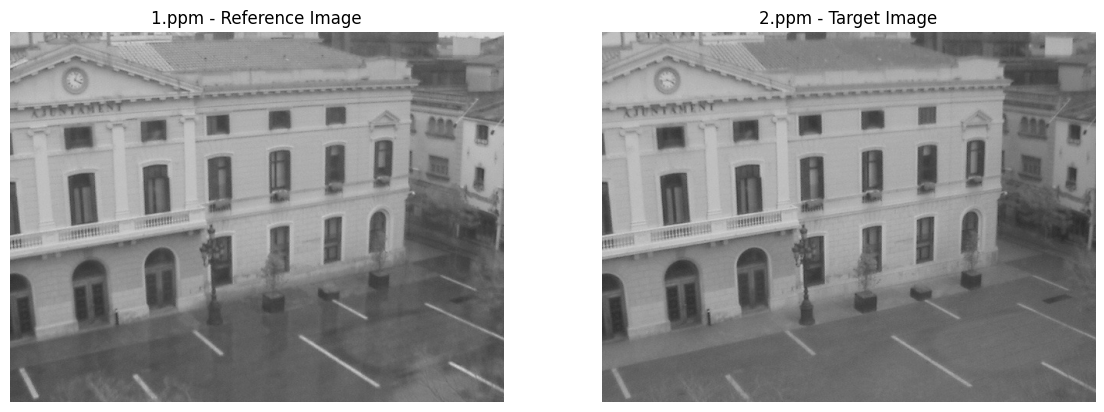

Image 1 shape: (480, 640, 3)
Image 2 shape: (480, 640, 3)


In [336]:
import cv2
import matplotlib.pyplot as plt
import os

# Folder containing the i_ajuntament sequence
sequence_path = "/content/i_ajuntament"

# Load reference and target images
img1_path = os.path.join(sequence_path, "1.ppm")
img2_path = os.path.join(sequence_path, "2.ppm")

img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# OpenCV loads images in BGR, so convert to RGB for displaying
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Display side by side
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title("1.ppm - Reference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title("2.ppm - Target Image")
plt.axis("off")

plt.show()

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)

In [337]:
import numpy as np
import os

# Path to homography file
H_path = os.path.join(sequence_path, "H_1_2")

# Load the 3x3 homography matrix
H = np.loadtxt(H_path)

print("Homography H_1_2:")
print(H)

print("\nShape of H:", H.shape)

Homography H_1_2:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Shape of H: (3, 3)


# Stage B

Image shape: (480, 640)
Number of SIFT keypoints: 840
Descriptor shape: (840, 128)


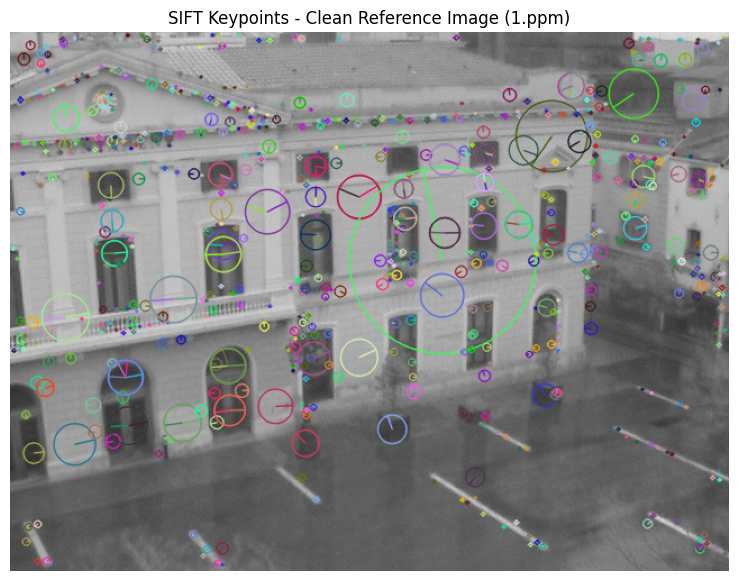

In [338]:
import cv2
import matplotlib.pyplot as plt
import os

# HPatches sequence folder
sequence_path = "/content/i_ajuntament"

# Load reference image directly as grayscale
img1_gray = cv2.imread(
    os.path.join(sequence_path, "1.ppm"),
    cv2.IMREAD_GRAYSCALE
)

# Check that image loaded correctly
print("Image shape:", img1_gray.shape)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)

# Print information
print("Number of SIFT keypoints:", len(keypoints1))
print("Descriptor shape:", descriptors1.shape)

# Draw detected keypoints
img1_keypoints = cv2.drawKeypoints(
    img1_gray,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display
plt.figure(figsize=(10, 7))
plt.imshow(img1_keypoints, cmap="gray")
plt.title("SIFT Keypoints - Clean Reference Image (1.ppm)")
plt.axis("off")
plt.show()

In [339]:
# Look at the first detected SIFT keypoint
kp = keypoints1[0]

print("First keypoint information:")
print("Location (x, y):", kp.pt)
print("Size / scale:", kp.size)
print("Orientation angle:", kp.angle)
print("Response strength:", kp.response)

print("\nDescriptor information:")
print("Descriptor length:", len(descriptors1[0]))
print("First 10 descriptor values:")
print(descriptors1[0][:10])

First keypoint information:
Location (x, y): (2.3561851978302, 192.6036834716797)
Size / scale: 2.5694053173065186
Orientation angle: 273.7665710449219
Response strength: 0.017623091116547585

Descriptor information:
Descriptor length: 128
First 10 descriptor values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Image 2 shape: (480, 640)
Number of SIFT keypoints in 2.ppm: 780
Descriptor shape: (780, 128)


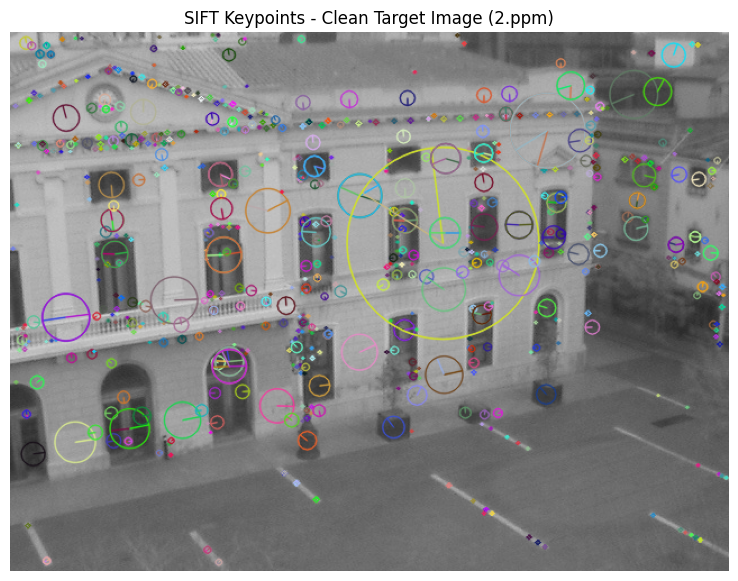

In [340]:
# Load target image as grayscale
img2_gray = cv2.imread(
    os.path.join(sequence_path, "2.ppm"),
    cv2.IMREAD_GRAYSCALE
)

# Detect SIFT keypoints and descriptors
keypoints2, descriptors2 = sift.detectAndCompute(img2_gray, None)

# Print results
print("Image 2 shape:", img2_gray.shape)
print("Number of SIFT keypoints in 2.ppm:", len(keypoints2))
print("Descriptor shape:", descriptors2.shape)

# Draw keypoints
img2_keypoints = cv2.drawKeypoints(
    img2_gray,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display image
plt.figure(figsize=(10, 7))
plt.imshow(img2_keypoints, cmap="gray")
plt.title("SIFT Keypoints - Clean Target Image (2.ppm)")
plt.axis("off")
plt.show()

In [341]:
# Clean-image SIFT baseline comparison

count1 = len(keypoints1)
count2 = len(keypoints2)

difference = count1 - count2
retention = (count2 / count1) * 100

print("===== SIFT CLEAN BASELINE =====")
print("1.ppm keypoints:", count1)
print("2.ppm keypoints:", count2)
print("Difference:", difference)
print("Keypoint retention:", round(retention, 2), "%")

===== SIFT CLEAN BASELINE =====
1.ppm keypoints: 840
2.ppm keypoints: 780
Difference: 60
Keypoint retention: 92.86 %


# Stage C

In [342]:
# Create a Brute-Force matcher for SIFT descriptors
bf = cv2.BFMatcher(cv2.NORM_L2)

# For every descriptor in image 1,
# find the two closest descriptors in image 2
matches_knn = bf.knnMatch(
    descriptors1,
    descriptors2,
    k=2
)

print("Number of descriptor match groups:", len(matches_knn))

# Look at the first match group
m, n = matches_knn[0]

print("\nFirst candidate match:")
print("Best match distance:", m.distance)
print("Second-best match distance:", n.distance)

print("\nKeypoint index in image 1:", m.queryIdx)
print("Matched keypoint index in image 2:", m.trainIdx)

Number of descriptor match groups: 840

First candidate match:
Best match distance: 47.97916030883789
Second-best match distance: 272.3728942871094

Keypoint index in image 1: 0
Matched keypoint index in image 2: 0


In [343]:
# Lowe's ratio-test threshold
ratio_threshold = 0.75

good_matches = []

for m, n in matches_knn:
    if m.distance < ratio_threshold * n.distance:
        good_matches.append(m)

print("Total candidate match groups:", len(matches_knn))
print("Good matches after ratio test:", len(good_matches))

percentage = (len(good_matches) / len(matches_knn)) * 100

print("Percentage retained:", round(percentage, 2), "%")

Total candidate match groups: 840
Good matches after ratio test: 348
Percentage retained: 41.43 %


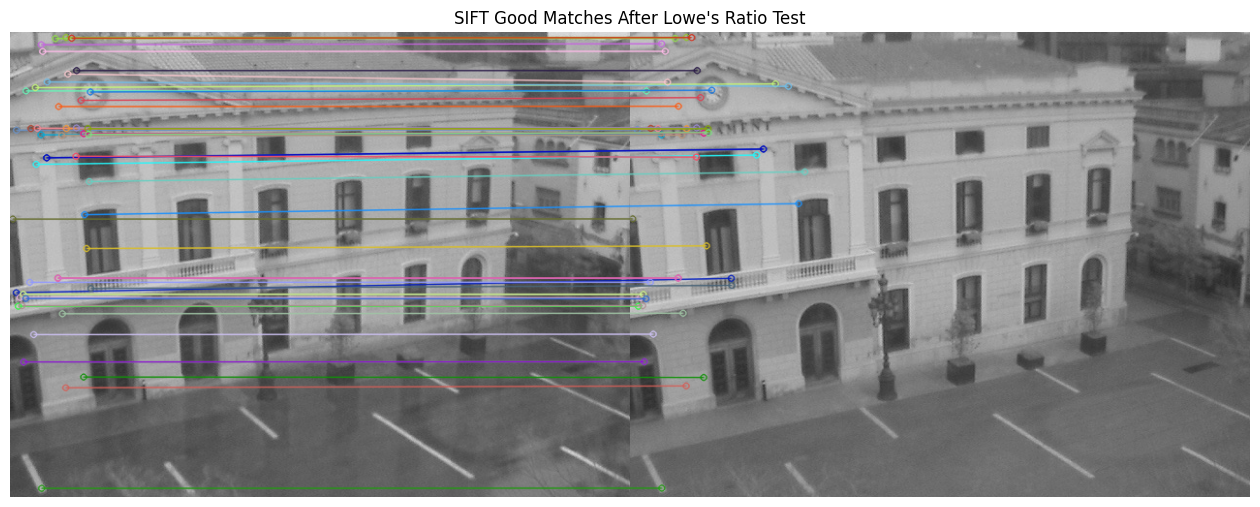

In [344]:
# Draw the first 50 good matches for clear visualization
matched_image = cv2.drawMatches(
    img1_gray,
    keypoints1,
    img2_gray,
    keypoints2,
    good_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(matched_image, cmap="gray")
plt.title("SIFT Good Matches After Lowe's Ratio Test")
plt.axis("off")
plt.show()

In [345]:
print("===== SIFT CLEAN MATCHING BASELINE =====")

print("Reference keypoints:", len(keypoints1))
print("Target keypoints:", len(keypoints2))

print("Candidate match groups:", len(matches_knn))
print("Good ratio-test matches:", len(good_matches))

print("Ratio threshold:", ratio_threshold)
print("Good-match percentage:", round(
    len(good_matches) / len(matches_knn) * 100, 2
), "%")

===== SIFT CLEAN MATCHING BASELINE =====
Reference keypoints: 840
Target keypoints: 780
Candidate match groups: 840
Good ratio-test matches: 348
Ratio threshold: 0.75
Good-match percentage: 41.43 %


# Stage D

In [346]:
import numpy as np
import cv2

# Maximum allowed geometric error
geometric_threshold = 5.0  # pixels

correct_matches = []
incorrect_matches = []
geometric_errors = []

for match in good_matches:

    # Keypoint location in reference image
    x1, y1 = keypoints1[match.queryIdx].pt

    # Convert point into format required by perspectiveTransform
    point1 = np.array([[[x1, y1]]], dtype=np.float32)

    # Use HPatches ground-truth homography
    predicted_point = cv2.perspectiveTransform(point1, H)

    predicted_x, predicted_y = predicted_point[0][0]

    # Actual matched keypoint location in image 2
    x2, y2 = keypoints2[match.trainIdx].pt

    # Euclidean geometric error
    error = np.sqrt(
        (predicted_x - x2) ** 2 +
        (predicted_y - y2) ** 2
    )

    geometric_errors.append(error)

    if error <= geometric_threshold:
        correct_matches.append(match)
    else:
        incorrect_matches.append(match)


print("===== GEOMETRIC VERIFICATION =====")
print("Good descriptor matches:", len(good_matches))
print("Geometrically correct matches:", len(correct_matches))
print("Geometrically incorrect matches:", len(incorrect_matches))

matching_accuracy = (
    len(correct_matches) / len(good_matches)
) * 100

print("Geometric matching accuracy:",
      round(matching_accuracy, 2), "%")

print("Mean geometric error:",
      round(np.mean(geometric_errors), 3), "pixels")

print("Median geometric error:",
      round(np.median(geometric_errors), 3), "pixels")

===== GEOMETRIC VERIFICATION =====
Good descriptor matches: 348
Geometrically correct matches: 286
Geometrically incorrect matches: 62
Geometric matching accuracy: 82.18 %
Mean geometric error: 21.99 pixels
Median geometric error: 0.717 pixels


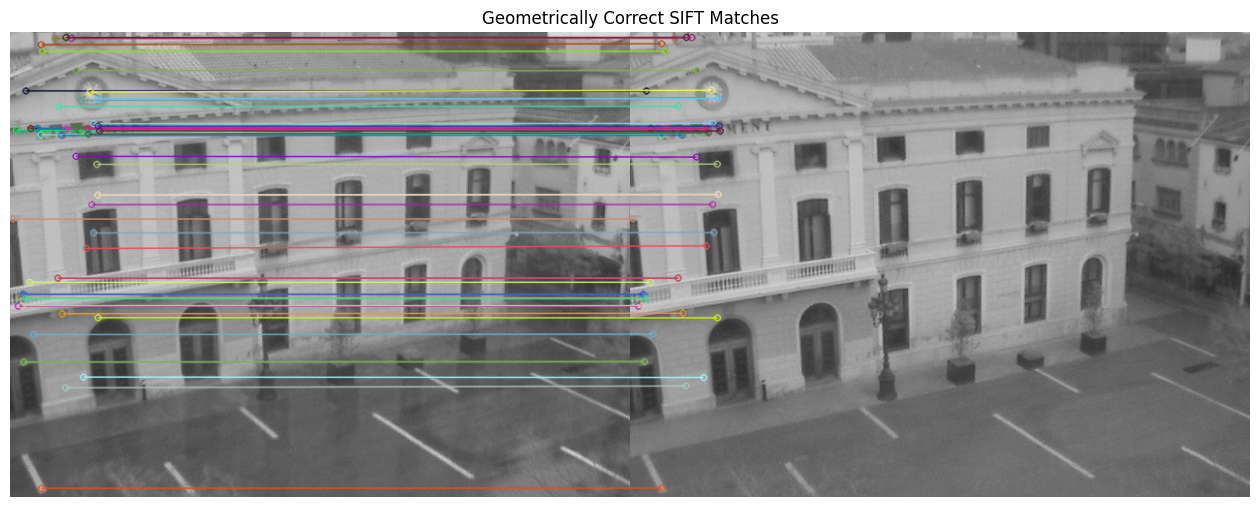

In [347]:
# Visualize geometrically correct matches
correct_vis = cv2.drawMatches(
    img1_gray,
    keypoints1,
    img2_gray,
    keypoints2,
    correct_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(correct_vis, cmap="gray")
plt.title("Geometrically Correct SIFT Matches")
plt.axis("off")
plt.show()

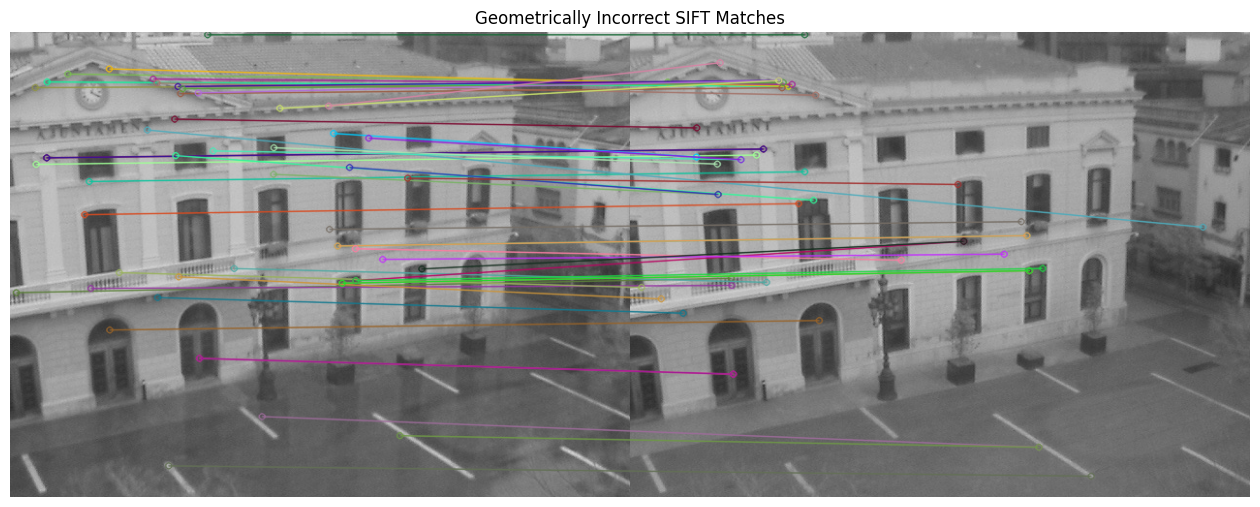

In [348]:
# Visualize geometrically incorrect matches
incorrect_vis = cv2.drawMatches(
    img1_gray,
    keypoints1,
    img2_gray,
    keypoints2,
    incorrect_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(incorrect_vis, cmap="gray")
plt.title("Geometrically Incorrect SIFT Matches")
plt.axis("off")
plt.show()

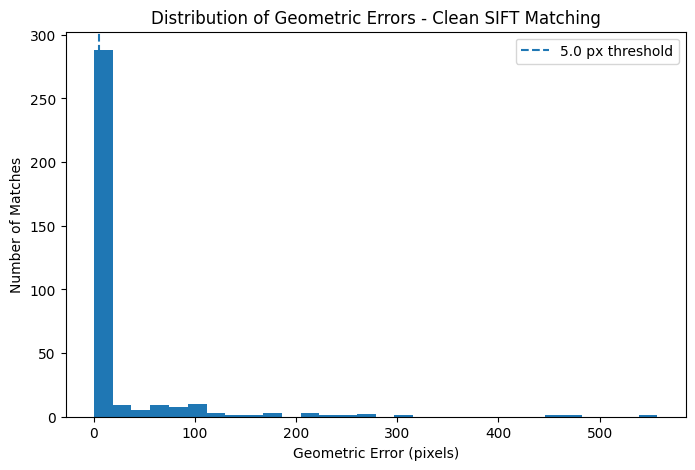

Minimum error: 0.081 pixels
Median error: 0.717 pixels
Mean error: 21.99 pixels
90th percentile: 79.758 pixels
Maximum error: 557.206 pixels


In [349]:
import matplotlib.pyplot as plt
import numpy as np

errors = np.array(geometric_errors)

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30)

# Show our current correctness threshold
plt.axvline(
    geometric_threshold,
    linestyle="--",
    label=f"{geometric_threshold} px threshold"
)

plt.xlabel("Geometric Error (pixels)")
plt.ylabel("Number of Matches")
plt.title("Distribution of Geometric Errors - Clean SIFT Matching")
plt.legend()

plt.show()

print("Minimum error:", round(np.min(errors), 3), "pixels")
print("Median error:", round(np.median(errors), 3), "pixels")
print("Mean error:", round(np.mean(errors), 3), "pixels")
print("90th percentile:", round(np.percentile(errors, 90), 3), "pixels")
print("Maximum error:", round(np.max(errors), 3), "pixels")

# Stage E

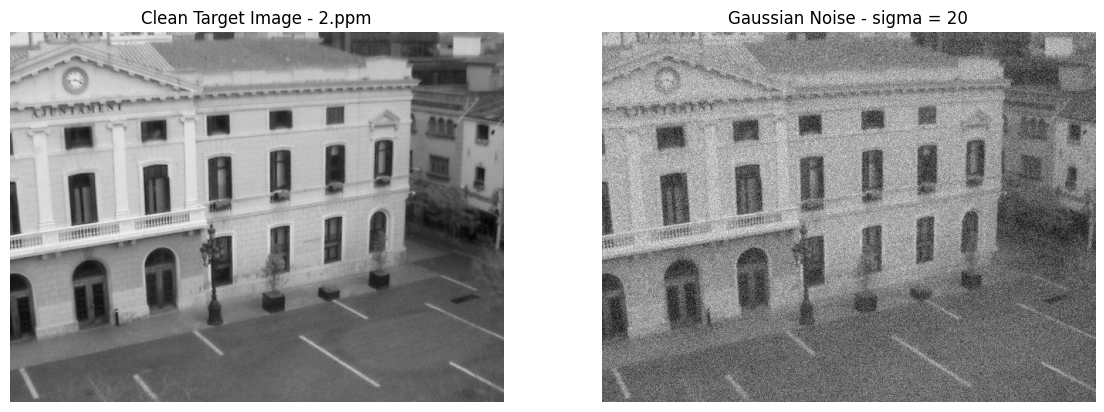

Clean image shape: (480, 640)
Noisy image shape: (480, 640)
Noise sigma: 20
Clean pixel range: 40 - 214
Noisy pixel range: 0 - 255


In [350]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility: gives the same random noise each time
np.random.seed(42)

# Noise strength
sigma = 20

# Generate Gaussian noise
noise = np.random.normal(
    loc=0,
    scale=sigma,
    size=img2_gray.shape
)

# Add noise to clean target image
noisy_img2 = img2_gray.astype(np.float32) + noise

# Keep pixel values inside valid image range
noisy_img2 = np.clip(noisy_img2, 0, 255)

# Convert back to 8-bit image
noisy_img2 = noisy_img2.astype(np.uint8)

# Display clean vs noisy target image
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img2_gray, cmap="gray")
plt.title("Clean Target Image - 2.ppm")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_img2, cmap="gray")
plt.title("Gaussian Noise - sigma = 20")
plt.axis("off")

plt.show()

print("Clean image shape:", img2_gray.shape)
print("Noisy image shape:", noisy_img2.shape)
print("Noise sigma:", sigma)
print("Clean pixel range:", img2_gray.min(), "-", img2_gray.max())
print("Noisy pixel range:", noisy_img2.min(), "-", noisy_img2.max())

In [351]:
# Detect SIFT features on the noisy target image
noisy_keypoints2, noisy_descriptors2 = sift.detectAndCompute(
    noisy_img2,
    None
)

print("===== SIFT ON NOISY IMAGE =====")
print("Noise sigma:", sigma)
print("Clean target keypoints:", len(keypoints2))
print("Noisy target keypoints:", len(noisy_keypoints2))

difference = len(noisy_keypoints2) - len(keypoints2)

print("Difference:", difference)

if noisy_descriptors2 is not None:
    print("Noisy descriptor shape:", noisy_descriptors2.shape)
else:
    print("No descriptors detected.")

===== SIFT ON NOISY IMAGE =====
Noise sigma: 20
Clean target keypoints: 780
Noisy target keypoints: 1188
Difference: 408
Noisy descriptor shape: (1188, 128)


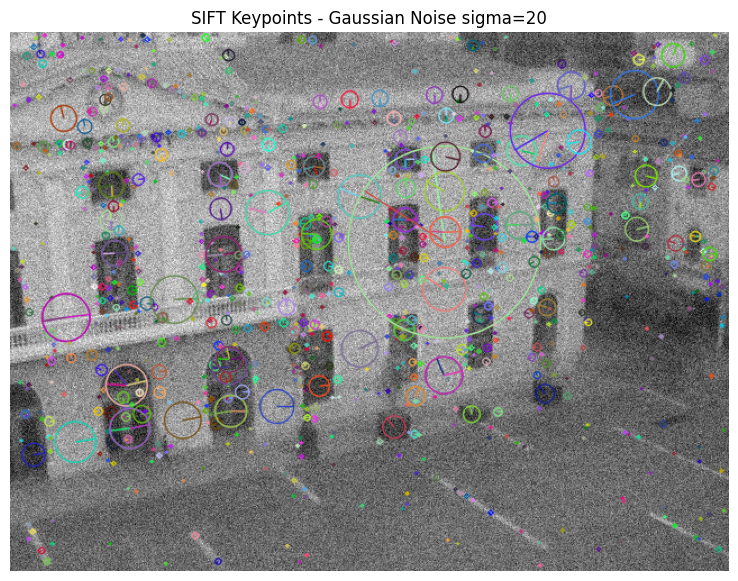

In [352]:
noisy_keypoint_img = cv2.drawKeypoints(
    noisy_img2,
    noisy_keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 7))
plt.imshow(noisy_keypoint_img, cmap="gray")
plt.title(f"SIFT Keypoints - Gaussian Noise sigma={sigma}")
plt.axis("off")
plt.show()

In [353]:
# Match clean reference descriptors with noisy target descriptors
noisy_matches_knn = bf.knnMatch(
    descriptors1,
    noisy_descriptors2,
    k=2
)

# Apply the same Lowe ratio test
noisy_good_matches = []

for m, n in noisy_matches_knn:
    if m.distance < ratio_threshold * n.distance:
        noisy_good_matches.append(m)

print("===== CLEAN vs NOISY MATCHING =====")
print("Noise sigma:", sigma)
print("Candidate match groups:", len(noisy_matches_knn))
print("Good ratio-test matches:", len(noisy_good_matches))

noisy_good_percentage = (
    len(noisy_good_matches) / len(noisy_matches_knn)
) * 100

print("Good-match percentage:",
      round(noisy_good_percentage, 2), "%")

===== CLEAN vs NOISY MATCHING =====
Noise sigma: 20
Candidate match groups: 840
Good ratio-test matches: 190
Good-match percentage: 22.62 %


In [354]:
noisy_correct_matches = []
noisy_incorrect_matches = []
noisy_geometric_errors = []

for match in noisy_good_matches:

    # Reference-image keypoint
    x1, y1 = keypoints1[match.queryIdx].pt

    point1 = np.array([[[x1, y1]]], dtype=np.float32)

    # Predict where the point should appear in image 2
    predicted_point = cv2.perspectiveTransform(point1, H)

    predicted_x, predicted_y = predicted_point[0][0]

    # Actual matched point in noisy image 2
    x2, y2 = noisy_keypoints2[match.trainIdx].pt

    # Geometric error
    error = np.sqrt(
        (predicted_x - x2) ** 2 +
        (predicted_y - y2) ** 2
    )

    noisy_geometric_errors.append(error)

    if error <= geometric_threshold:
        noisy_correct_matches.append(match)
    else:
        noisy_incorrect_matches.append(match)


noisy_matching_accuracy = (
    len(noisy_correct_matches) / len(noisy_good_matches)
) * 100

print("===== NOISY GEOMETRIC VERIFICATION =====")
print("Noise sigma:", sigma)
print("Good descriptor matches:", len(noisy_good_matches))
print("Geometrically correct matches:", len(noisy_correct_matches))
print("Geometrically incorrect matches:", len(noisy_incorrect_matches))
print("Geometric matching accuracy:",
      round(noisy_matching_accuracy, 2), "%")
print("Median geometric error:",
      round(np.median(noisy_geometric_errors), 3), "pixels")

===== NOISY GEOMETRIC VERIFICATION =====
Noise sigma: 20
Good descriptor matches: 190
Geometrically correct matches: 133
Geometrically incorrect matches: 57
Geometric matching accuracy: 70.0 %
Median geometric error: 1.38 pixels


In [355]:
noise_levels = [0, 5, 10, 15, 20, 25, 30, 40, 50]

noise_results = []

for sigma_level in noise_levels:

    # Keep clean image for sigma = 0
    if sigma_level == 0:
        test_img = img2_gray.copy()

    else:
        # Reproducible noise
        rng = np.random.default_rng(42 + sigma_level)

        noise = rng.normal(
            0,
            sigma_level,
            img2_gray.shape
        )

        test_img = img2_gray.astype(np.float32) + noise
        test_img = np.clip(test_img, 0, 255).astype(np.uint8)

    # SIFT detection
    kp_test, desc_test = sift.detectAndCompute(test_img, None)

    # Safety check
    if desc_test is None or len(kp_test) < 2:
        noise_results.append({
            "sigma": sigma_level,
            "keypoints": len(kp_test),
            "good_matches": 0,
            "correct_matches": 0,
            "accuracy": 0,
            "median_error": np.nan
        })
        continue

    # Descriptor matching
    matches = bf.knnMatch(
        descriptors1,
        desc_test,
        k=2
    )

    # Lowe ratio test
    good = []

    for m, n in matches:
        if m.distance < ratio_threshold * n.distance:
            good.append(m)

    # Geometric verification
    correct = []
    errors = []

    for match in good:

        x1, y1 = keypoints1[match.queryIdx].pt

        point1 = np.array(
            [[[x1, y1]]],
            dtype=np.float32
        )

        predicted = cv2.perspectiveTransform(
            point1,
            H
        )[0][0]

        x2, y2 = kp_test[match.trainIdx].pt

        error = np.sqrt(
            (predicted[0] - x2) ** 2 +
            (predicted[1] - y2) ** 2
        )

        errors.append(error)

        if error <= geometric_threshold:
            correct.append(match)

    # Metrics
    accuracy = (
        len(correct) / len(good) * 100
        if len(good) > 0 else 0
    )

    median_error = (
        np.median(errors)
        if len(errors) > 0 else np.nan
    )

    noise_results.append({
        "sigma": sigma_level,
        "keypoints": len(kp_test),
        "good_matches": len(good),
        "correct_matches": len(correct),
        "accuracy": accuracy,
        "median_error": median_error
    })


# Print results
print(
    f"{'Sigma':<8}"
    f"{'Keypoints':<12}"
    f"{'Good':<10}"
    f"{'Correct':<10}"
    f"{'Accuracy':<12}"
    f"{'Median Error'}"
)

print("-" * 65)

for r in noise_results:
    print(
        f"{r['sigma']:<8}"
        f"{r['keypoints']:<12}"
        f"{r['good_matches']:<10}"
        f"{r['correct_matches']:<10}"
        f"{r['accuracy']:<12.2f}"
        f"{r['median_error']:.3f}"
    )

Sigma   Keypoints   Good      Correct   Accuracy    Median Error
-----------------------------------------------------------------
0       780         348       286       82.18       0.717
5       902         313       268       85.62       0.741
10      1032        248       211       85.08       0.846
15      1141        202       160       79.21       1.142
20      1185        192       134       69.79       1.512
25      1308        150       118       78.67       1.334
30      1340        140       100       71.43       1.597
40      1361        106       86        81.13       1.781
50      1347        108       68        62.96       2.438


In [356]:
# Clean baseline correct-match count
clean_correct = noise_results[0]["correct_matches"]

# Calculate correct-match retention for every noise level
for r in noise_results:
    r["correct_retention"] = (
        r["correct_matches"] / clean_correct
    ) * 100


print(
    f"{'Sigma':<8}"
    f"{'Correct':<12}"
    f"{'Retention (%)':<15}"
    f"{'Accuracy (%)':<15}"
    f"{'Median Error'}"
)

print("-" * 65)

for r in noise_results:
    print(
        f"{r['sigma']:<8}"
        f"{r['correct_matches']:<12}"
        f"{r['correct_retention']:<15.2f}"
        f"{r['accuracy']:<15.2f}"
        f"{r['median_error']:.3f}"
    )

Sigma   Correct     Retention (%)  Accuracy (%)   Median Error
-----------------------------------------------------------------
0       286         100.00         82.18          0.717
5       268         93.71          85.62          0.741
10      211         73.78          85.08          0.846
15      160         55.94          79.21          1.142
20      134         46.85          69.79          1.512
25      118         41.26          78.67          1.334
30      100         34.97          71.43          1.597
40      86          30.07          81.13          1.781
50      68          23.78          62.96          2.438


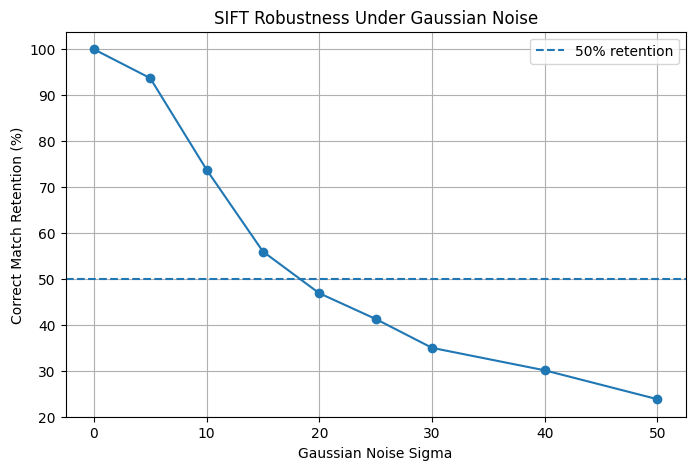

In [357]:
sigmas = [r["sigma"] for r in noise_results]
retentions = [r["correct_retention"] for r in noise_results]

plt.figure(figsize=(8, 5))

plt.plot(
    sigmas,
    retentions,
    marker="o"
)

plt.axhline(
    50,
    linestyle="--",
    label="50% retention"
)

plt.xlabel("Gaussian Noise Sigma")
plt.ylabel("Correct Match Retention (%)")
plt.title("SIFT Robustness Under Gaussian Noise")

plt.grid(True)
plt.legend()
plt.show()

In [358]:
failure_threshold = None

for r in noise_results:
    if r["correct_retention"] < 50:
        failure_threshold = r["sigma"]
        break

print("===== GAUSSIAN NOISE FAILURE THRESHOLD =====")

if failure_threshold is not None:
    print("First tested sigma below 50% retention:", failure_threshold)
else:
    print("No failure threshold reached in tested range.")

===== GAUSSIAN NOISE FAILURE THRESHOLD =====
First tested sigma below 50% retention: 20


# Stage F

In [359]:
def evaluate_sift(test_img):

    # Detect features
    kp_test, desc_test = sift.detectAndCompute(test_img, None)

    if desc_test is None or len(kp_test) < 2:
        return len(kp_test), 0, 0, 0, np.nan

    # Match descriptors
    matches = bf.knnMatch(descriptors1, desc_test, k=2)

    # Lowe ratio test
    good = []

    for m, n in matches:
        if m.distance < ratio_threshold * n.distance:
            good.append(m)

    # Geometric verification
    correct = []
    errors = []

    for match in good:

        x1, y1 = keypoints1[match.queryIdx].pt

        point1 = np.array(
            [[[x1, y1]]],
            dtype=np.float32
        )

        predicted = cv2.perspectiveTransform(
            point1, H
        )[0][0]

        x2, y2 = kp_test[match.trainIdx].pt

        error = np.sqrt(
            (predicted[0] - x2) ** 2 +
            (predicted[1] - y2) ** 2
        )

        errors.append(error)

        if error <= geometric_threshold:
            correct.append(match)

    accuracy = (
        len(correct) / len(good) * 100
        if len(good) > 0 else 0
    )

    median_error = (
        np.median(errors)
        if len(errors) > 0 else np.nan
    )

    return (
        len(kp_test),
        len(good),
        len(correct),
        accuracy,
        median_error
    )

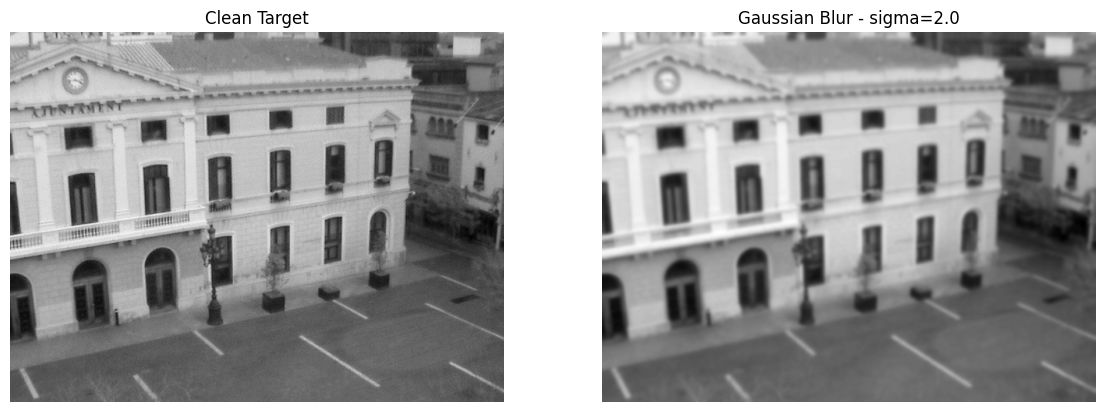

In [360]:
blur_sigma = 2.0

blurred_img2 = cv2.GaussianBlur(
    img2_gray,
    (0, 0),
    sigmaX=blur_sigma
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img2_gray, cmap="gray")
plt.title("Clean Target")

plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_img2, cmap="gray")
plt.title(f"Gaussian Blur - sigma={blur_sigma}")

plt.axis("off")

plt.show()

In [361]:
def evaluate_sift(test_img):

    kp_test, desc_test = sift.detectAndCompute(test_img, None)

    if desc_test is None or len(kp_test) < 2:
        return len(kp_test), 0, 0, 0, np.nan

    matches = bf.knnMatch(descriptors1, desc_test, k=2)

    good = []

    for m, n in matches:
        if m.distance < ratio_threshold * n.distance:
            good.append(m)

    correct = []
    errors = []

    for match in good:

        x1, y1 = keypoints1[match.queryIdx].pt

        point1 = np.array(
            [[[x1, y1]]],
            dtype=np.float32
        )

        predicted = cv2.perspectiveTransform(
            point1,
            H
        )[0][0]

        x2, y2 = kp_test[match.trainIdx].pt

        error = np.sqrt(
            (predicted[0] - x2) ** 2 +
            (predicted[1] - y2) ** 2
        )

        errors.append(error)

        if error <= geometric_threshold:
            correct.append(match)

    accuracy = (
        len(correct) / len(good) * 100
        if len(good) > 0 else 0
    )

    median_error = (
        np.median(errors)
        if len(errors) > 0 else np.nan
    )

    return (
        len(kp_test),
        len(good),
        len(correct),
        accuracy,
        median_error
    )

In [362]:
kp_blur, good_blur, correct_blur, accuracy_blur, error_blur = evaluate_sift(
    blurred_img2
)

print("===== SIFT UNDER GAUSSIAN BLUR =====")
print("Blur sigma:", blur_sigma)
print("Keypoints:", kp_blur)
print("Good matches:", good_blur)
print("Correct matches:", correct_blur)
print("Matching accuracy:", round(accuracy_blur, 2), "%")
print("Median geometric error:", round(error_blur, 3), "pixels")

===== SIFT UNDER GAUSSIAN BLUR =====
Blur sigma: 2.0
Keypoints: 230
Good matches: 156
Correct matches: 115
Matching accuracy: 73.72 %
Median geometric error: 1.227 pixels


In [363]:
blur_levels = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

blur_results = []

for blur_sigma in blur_levels:

    if blur_sigma == 0:
        test_img = img2_gray.copy()
    else:
        test_img = cv2.GaussianBlur(
            img2_gray,
            (0, 0),
            sigmaX=blur_sigma
        )

    kp, good, correct, accuracy, median_error = evaluate_sift(test_img)

    retention = (correct / 286) * 100

    blur_results.append({
        "sigma": blur_sigma,
        "keypoints": kp,
        "good_matches": good,
        "correct_matches": correct,
        "retention": retention,
        "accuracy": accuracy,
        "median_error": median_error
    })


print(
    f"{'Sigma':<8}"
    f"{'Keypoints':<12}"
    f"{'Good':<10}"
    f"{'Correct':<10}"
    f"{'Retention':<12}"
    f"{'Accuracy':<12}"
    f"{'Median Error'}"
)

print("-" * 80)

for r in blur_results:
    print(
        f"{r['sigma']:<8}"
        f"{r['keypoints']:<12}"
        f"{r['good_matches']:<10}"
        f"{r['correct_matches']:<10}"
        f"{r['retention']:<12.2f}"
        f"{r['accuracy']:<12.2f}"
        f"{r['median_error']:.3f}"
    )

Sigma   Keypoints   Good      Correct   Retention   Accuracy    Median Error
--------------------------------------------------------------------------------
0       780         348       286       100.00      82.18       0.717
0.5     650         314       268       93.71       85.35       0.669
1.0     404         240       201       70.28       83.75       0.820
1.5     305         182       151       52.80       82.97       0.970
2.0     230         156       115       40.21       73.72       1.227
2.5     180         136       90        31.47       66.18       1.662
3.0     152         105       71        24.83       67.62       1.929
4.0     105         70        44        15.38       62.86       2.256
5.0     98          51        38        13.29       74.51       1.837


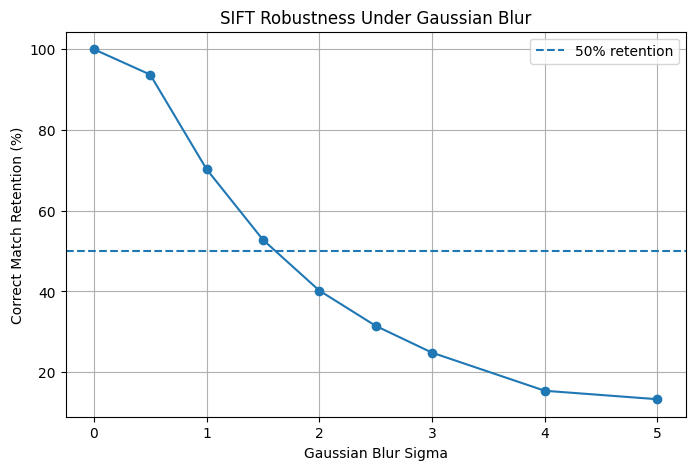

In [364]:
blur_sigmas = [r["sigma"] for r in blur_results]
blur_retentions = [r["retention"] for r in blur_results]

plt.figure(figsize=(8, 5))

plt.plot(
    blur_sigmas,
    blur_retentions,
    marker="o"
)

plt.axhline(
    50,
    linestyle="--",
    label="50% retention"
)

plt.xlabel("Gaussian Blur Sigma")
plt.ylabel("Correct Match Retention (%)")
plt.title("SIFT Robustness Under Gaussian Blur")

plt.grid(True)
plt.legend()
plt.show()

In [365]:
blur_failure_threshold = None

for r in blur_results:
    if r["retention"] < 50:
        blur_failure_threshold = r["sigma"]
        break

print("===== GAUSSIAN BLUR FAILURE THRESHOLD =====")

if blur_failure_threshold is not None:
    print(
        "First tested blur sigma below 50% retention:",
        blur_failure_threshold
    )
else:
    print("No failure threshold reached.")

===== GAUSSIAN BLUR FAILURE THRESHOLD =====
First tested blur sigma below 50% retention: 2.0


# Stage G

In [366]:
light_factor = 0.5

dark_img2 = (
    img2_gray.astype(np.float32) * light_factor
)

dark_img2 = np.clip(
    dark_img2,
    0,
    255
).astype(np.uint8)

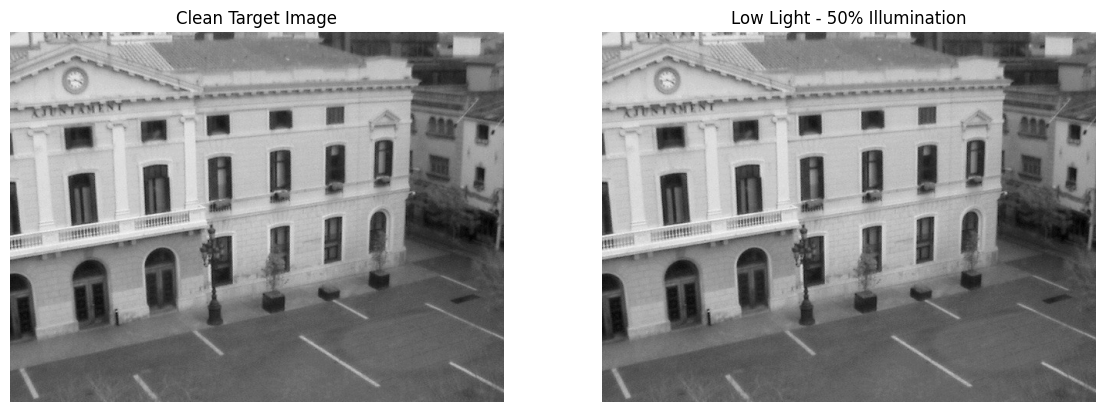

In [367]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img2_gray, cmap="gray")
plt.title("Clean Target Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dark_img2, cmap="gray")
plt.title(f"Low Light - {int(light_factor * 100)}% Illumination")
plt.axis("off")

plt.show()

In [368]:
kp_dark, good_dark, correct_dark, accuracy_dark, error_dark = evaluate_sift(
    dark_img2
)

dark_retention = (
    correct_dark / 286
) * 100

print("===== SIFT UNDER LOW LIGHT =====")
print("Illumination:", int(light_factor * 100), "%")
print("Keypoints:", kp_dark)
print("Good matches:", good_dark)
print("Correct matches:", correct_dark)
print("Correct-match retention:", round(dark_retention, 2), "%")
print("Matching accuracy:", round(accuracy_dark, 2), "%")
print("Median geometric error:", round(error_dark, 3), "pixels")

===== SIFT UNDER LOW LIGHT =====
Illumination: 50 %
Keypoints: 153
Good matches: 130
Correct matches: 84
Correct-match retention: 29.37 %
Matching accuracy: 64.62 %
Median geometric error: 1.122 pixels


In [369]:
light_levels = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

light_results = []

for factor in light_levels:

    test_img = (
        img2_gray.astype(np.float32) * factor
    )

    test_img = np.clip(
        test_img,
        0,
        255
    ).astype(np.uint8)

    kp, good, correct, accuracy, median_error = evaluate_sift(test_img)

    retention = (correct / 286) * 100

    light_results.append({
        "factor": factor,
        "illumination_percent": int(factor * 100),
        "keypoints": kp,
        "good_matches": good,
        "correct_matches": correct,
        "retention": retention,
        "accuracy": accuracy,
        "median_error": median_error
    })


print(
    f"{'Light %':<10}"
    f"{'Keypoints':<12}"
    f"{'Good':<10}"
    f"{'Correct':<10}"
    f"{'Retention':<12}"
    f"{'Accuracy':<12}"
    f"{'Median Error'}"
)

print("-" * 82)

for r in light_results:
    print(
        f"{r['illumination_percent']:<10}"
        f"{r['keypoints']:<12}"
        f"{r['good_matches']:<10}"
        f"{r['correct_matches']:<10}"
        f"{r['retention']:<12.2f}"
        f"{r['accuracy']:<12.2f}"
        f"{r['median_error']:.3f}"
    )

Light %   Keypoints   Good      Correct   Retention   Accuracy    Median Error
----------------------------------------------------------------------------------
100       780         348       286       100.00      82.18       0.717
90        646         301       256       89.51       85.05       0.650
80        540         256       216       75.52       84.38       0.642
70        405         228       179       62.59       78.51       0.797
60        266         188       135       47.20       71.81       0.930
50        153         130       84        29.37       64.62       1.122
40        69          55        38        13.29       69.09       1.093
30        14          13        8         2.80        61.54       0.898
20        0           0         0         0.00        0.00        nan
10        0           0         0         0.00        0.00        nan


In [370]:
light_failure_threshold = None

for r in light_results:
    if r["retention"] < 50:
        light_failure_threshold = r["illumination_percent"]
        break

print("===== LOW-LIGHT FAILURE THRESHOLD =====")

if light_failure_threshold is not None:
    print(
        "First tested illumination level below 50% retention:",
        light_failure_threshold,
        "%"
    )
else:
    print("No failure threshold reached.")

===== LOW-LIGHT FAILURE THRESHOLD =====
First tested illumination level below 50% retention: 60 %


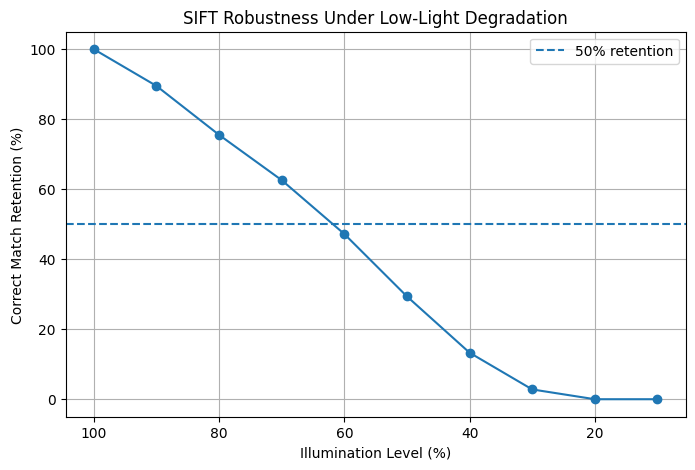

In [371]:
light_percentages = [
    r["illumination_percent"]
    for r in light_results
]

light_retentions = [
    r["retention"]
    for r in light_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    light_percentages,
    light_retentions,
    marker="o"
)

plt.axhline(
    50,
    linestyle="--",
    label="50% retention"
)

plt.xlabel("Illumination Level (%)")
plt.ylabel("Correct Match Retention (%)")
plt.title("SIFT Robustness Under Low-Light Degradation")

plt.grid(True)
plt.legend()

# Show normal → darker direction from left to right
plt.gca().invert_xaxis()

plt.show()

# Stage H

In [372]:
import cv2

print("OpenCV version:", cv2.__version__)
print("SIFT available:", hasattr(cv2, "SIFT_create"))
print("ORB available:", hasattr(cv2, "ORB_create"))
print("AKAZE available:", hasattr(cv2, "AKAZE_create"))

OpenCV version: 4.12.0
SIFT available: True
ORB available: True
AKAZE available: True


In [373]:
# Create ORB detector
orb = cv2.ORB_create(nfeatures=2000)

# Detect features in clean reference and target images
orb_kp1, orb_desc1 = orb.detectAndCompute(img1_gray, None)
orb_kp2, orb_desc2 = orb.detectAndCompute(img2_gray, None)

print("===== ORB CLEAN FEATURE DETECTION =====")
print("Reference keypoints:", len(orb_kp1))
print("Target keypoints:", len(orb_kp2))
print("Reference descriptor shape:", orb_desc1.shape)
print("Target descriptor shape:", orb_desc2.shape)

===== ORB CLEAN FEATURE DETECTION =====
Reference keypoints: 1942
Target keypoints: 1944
Reference descriptor shape: (1942, 32)
Target descriptor shape: (1944, 32)


In [374]:
# ORB uses Hamming distance
bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING)

orb_matches_knn = bf_orb.knnMatch(
    orb_desc1,
    orb_desc2,
    k=2
)

orb_good_matches = []

for m, n in orb_matches_knn:
    if m.distance < ratio_threshold * n.distance:
        orb_good_matches.append(m)

print("\n===== ORB CLEAN MATCHING =====")
print("Candidate match groups:", len(orb_matches_knn))
print("Good ratio-test matches:", len(orb_good_matches))


===== ORB CLEAN MATCHING =====
Candidate match groups: 1942
Good ratio-test matches: 803


In [375]:
orb_correct_matches = []
orb_errors = []

for match in orb_good_matches:

    x1, y1 = orb_kp1[match.queryIdx].pt

    point1 = np.array(
        [[[x1, y1]]],
        dtype=np.float32
    )

    predicted = cv2.perspectiveTransform(
        point1,
        H
    )[0][0]

    x2, y2 = orb_kp2[match.trainIdx].pt

    error = np.sqrt(
        (predicted[0] - x2) ** 2 +
        (predicted[1] - y2) ** 2
    )

    orb_errors.append(error)

    if error <= geometric_threshold:
        orb_correct_matches.append(match)

orb_accuracy = (
    len(orb_correct_matches) / len(orb_good_matches) * 100
    if len(orb_good_matches) > 0 else 0
)

print("\n===== ORB CLEAN GEOMETRIC VERIFICATION =====")
print("Good matches:", len(orb_good_matches))
print("Correct matches:", len(orb_correct_matches))
print("Matching accuracy:", round(orb_accuracy, 2), "%")
print(
    "Median geometric error:",
    round(np.median(orb_errors), 3),
    "pixels"
)


===== ORB CLEAN GEOMETRIC VERIFICATION =====
Good matches: 803
Correct matches: 747
Matching accuracy: 93.03 %
Median geometric error: 0.0 pixels


In [376]:
# Create AKAZE detector
akaze = cv2.AKAZE_create()

# Detect keypoints and descriptors
akaze_kp1, akaze_desc1 = akaze.detectAndCompute(img1_gray, None)
akaze_kp2, akaze_desc2 = akaze.detectAndCompute(img2_gray, None)

print("===== AKAZE CLEAN FEATURE DETECTION =====")
print("Reference keypoints:", len(akaze_kp1))
print("Target keypoints:", len(akaze_kp2))
print("Reference descriptor shape:", akaze_desc1.shape)
print("Target descriptor shape:", akaze_desc2.shape)

===== AKAZE CLEAN FEATURE DETECTION =====
Reference keypoints: 437
Target keypoints: 435
Reference descriptor shape: (437, 61)
Target descriptor shape: (435, 61)


In [377]:
# AKAZE default descriptor uses Hamming distance
bf_akaze = cv2.BFMatcher(cv2.NORM_HAMMING)

akaze_matches_knn = bf_akaze.knnMatch(
    akaze_desc1,
    akaze_desc2,
    k=2
)

akaze_good_matches = []

for m, n in akaze_matches_knn:
    if m.distance < ratio_threshold * n.distance:
        akaze_good_matches.append(m)

print("\n===== AKAZE CLEAN MATCHING =====")
print("Candidate match groups:", len(akaze_matches_knn))
print("Good matches:", len(akaze_good_matches))


===== AKAZE CLEAN MATCHING =====
Candidate match groups: 437
Good matches: 305


In [378]:
akaze_correct_matches = []
akaze_errors = []

for match in akaze_good_matches:

    x1, y1 = akaze_kp1[match.queryIdx].pt

    point1 = np.array(
        [[[x1, y1]]],
        dtype=np.float32
    )

    predicted = cv2.perspectiveTransform(
        point1,
        H
    )[0][0]

    x2, y2 = akaze_kp2[match.trainIdx].pt

    error = np.sqrt(
        (predicted[0] - x2) ** 2 +
        (predicted[1] - y2) ** 2
    )

    akaze_errors.append(error)

    if error <= geometric_threshold:
        akaze_correct_matches.append(match)

akaze_accuracy = (
    len(akaze_correct_matches) /
    len(akaze_good_matches) * 100
    if len(akaze_good_matches) > 0
    else 0
)

print("\n===== AKAZE CLEAN GEOMETRIC VERIFICATION =====")
print("Good matches:", len(akaze_good_matches))
print("Correct matches:", len(akaze_correct_matches))
print("Matching accuracy:", round(akaze_accuracy, 2), "%")
print(
    "Median geometric error:",
    round(np.median(akaze_errors), 3),
    "pixels"
)


===== AKAZE CLEAN GEOMETRIC VERIFICATION =====
Good matches: 305
Correct matches: 289
Matching accuracy: 94.75 %
Median geometric error: 0.488 pixels


In [379]:
def detect_harris(image):

    corners = cv2.goodFeaturesToTrack(
        image,
        maxCorners=2000,
        qualityLevel=0.01,
        minDistance=5,
        blockSize=3,
        useHarrisDetector=True,
        k=0.04
    )

    keypoints = []

    if corners is not None:
        for corner in corners:

            x, y = corner.ravel()

            keypoints.append(
                cv2.KeyPoint(
                    float(x),
                    float(y),
                    8
                )
            )

    return keypoints


harris_kp1 = detect_harris(img1_gray)
harris_kp2 = detect_harris(img2_gray)

print("===== HARRIS CLEAN FEATURE DETECTION =====")
print("Reference Harris keypoints:", len(harris_kp1))
print("Target Harris keypoints:", len(harris_kp2))

===== HARRIS CLEAN FEATURE DETECTION =====
Reference Harris keypoints: 470
Target Harris keypoints: 339


In [380]:
harris_sift = cv2.SIFT_create()

harris_kp1, harris_desc1 = harris_sift.compute(
    img1_gray,
    harris_kp1
)

harris_kp2, harris_desc2 = harris_sift.compute(
    img2_gray,
    harris_kp2
)

print("Reference descriptor shape:", harris_desc1.shape)
print("Target descriptor shape:", harris_desc2.shape)

Reference descriptor shape: (470, 128)
Target descriptor shape: (339, 128)


In [381]:
def detect_harris(image):

    corners = cv2.goodFeaturesToTrack(
        image,
        maxCorners=2000,
        qualityLevel=0.01,
        minDistance=5,
        blockSize=3,
        useHarrisDetector=True,
        k=0.04
    )

    keypoints = []

    if corners is not None:

        for corner in corners:

            x, y = corner.ravel()

            keypoints.append(
                cv2.KeyPoint(
                    float(x),
                    float(y),
                    8
                )
            )

    return keypoints

In [382]:
harris_kp1 = detect_harris(img1_gray)
harris_kp2 = detect_harris(img2_gray)

print("===== HARRIS CLEAN FEATURE DETECTION =====")
print("Reference keypoints:", len(harris_kp1))
print("Target keypoints:", len(harris_kp2))

===== HARRIS CLEAN FEATURE DETECTION =====
Reference keypoints: 470
Target keypoints: 339


In [383]:
harris_sift = cv2.SIFT_create()

harris_kp1, harris_desc1 = harris_sift.compute(
    img1_gray,
    harris_kp1
)

harris_kp2, harris_desc2 = harris_sift.compute(
    img2_gray,
    harris_kp2
)

print("Reference descriptor shape:", harris_desc1.shape)
print("Target descriptor shape:", harris_desc2.shape)

Reference descriptor shape: (470, 128)
Target descriptor shape: (339, 128)


In [384]:
bf_harris = cv2.BFMatcher(cv2.NORM_L2)

harris_matches_knn = bf_harris.knnMatch(
    harris_desc1,
    harris_desc2,
    k=2
)

harris_good_matches = []

for pair in harris_matches_knn:

    if len(pair) == 2:

        m, n = pair

        if m.distance < ratio_threshold * n.distance:
            harris_good_matches.append(m)

print("===== HARRIS + SIFT CLEAN MATCHING =====")
print("Candidate match groups:", len(harris_matches_knn))
print("Good matches:", len(harris_good_matches))

===== HARRIS + SIFT CLEAN MATCHING =====
Candidate match groups: 470
Good matches: 295


In [385]:
def verify_matches(
    kp1,
    kp2,
    matches,
    H_current
):

    correct = []
    errors = []

    for match in matches:

        # Keypoint from reference image
        x1, y1 = kp1[match.queryIdx].pt

        point1 = np.array(
            [[[x1, y1]]],
            dtype=np.float32
        )

        # Project reference keypoint into target image
        predicted = cv2.perspectiveTransform(
            point1,
            H_current
        )[0][0]

        # Actual matched keypoint in target image
        x2, y2 = kp2[match.trainIdx].pt

        # Geometric error
        error = np.sqrt(
            (predicted[0] - x2) ** 2 +
            (predicted[1] - y2) ** 2
        )

        errors.append(error)

        # Correct if within threshold
        if error <= geometric_threshold:
            correct.append(match)

    accuracy = (
        len(correct) / len(matches) * 100
        if len(matches) > 0
        else 0
    )

    median_error = (
        np.median(errors)
        if len(errors) > 0
        else np.nan
    )

    return correct, accuracy, median_error

In [386]:
harris_correct_matches, harris_accuracy, harris_median_error = verify_matches(
    harris_kp1,
    harris_kp2,
    harris_good_matches,
    H
)

print("===== HARRIS CLEAN GEOMETRIC VERIFICATION =====")
print("Good matches:", len(harris_good_matches))
print("Correct matches:", len(harris_correct_matches))
print("Matching accuracy:", round(harris_accuracy, 2), "%")
print(
    "Median geometric error:",
    round(harris_median_error, 3),
    "pixels"
)

===== HARRIS CLEAN GEOMETRIC VERIFICATION =====
Good matches: 295
Correct matches: 266
Matching accuracy: 90.17 %
Median geometric error: 1.0 pixels


In [387]:
sift_multi = cv2.SIFT_create()
orb_multi = cv2.ORB_create(nfeatures=2000)
akaze_multi = cv2.AKAZE_create()
harris_sift_multi = cv2.SIFT_create()

In [388]:
def extract_features(algorithm, image):

    if algorithm == "SIFT":
        kp, desc = sift_multi.detectAndCompute(image, None)
        norm = cv2.NORM_L2

    elif algorithm == "ORB":
        kp, desc = orb_multi.detectAndCompute(image, None)
        norm = cv2.NORM_HAMMING

    elif algorithm == "AKAZE":
        kp, desc = akaze_multi.detectAndCompute(image, None)
        norm = cv2.NORM_HAMMING

    elif algorithm == "HARRIS":

        kp = detect_harris(image)

        if len(kp) == 0:
            return [], None, cv2.NORM_L2

        kp, desc = harris_sift_multi.compute(
            image,
            kp
        )

        norm = cv2.NORM_L2

    else:
        raise ValueError("Unknown algorithm: " + algorithm)

    return kp, desc, norm

In [389]:
algorithms = [
    "SIFT",
    "ORB",
    "AKAZE",
    "HARRIS"
]

In [390]:
reference_features = {}

for algorithm in algorithms:

    kp, desc, norm = extract_features(
        algorithm,
        img1_gray
    )

    reference_features[algorithm] = {
        "keypoints": kp,
        "descriptors": desc,
        "norm": norm
    }

    print(
        algorithm,
        "reference keypoints:",
        len(kp)
    )

SIFT reference keypoints: 840
ORB reference keypoints: 1942
AKAZE reference keypoints: 437
HARRIS reference keypoints: 470


In [391]:
def evaluate_pair(
    algorithm,
    ref_img,
    target_img,
    H_current
):

    # Extract reference features
    ref_kp, ref_desc, norm = extract_features(
        algorithm,
        ref_img
    )

    # Extract target features
    target_kp, target_desc, _ = extract_features(
        algorithm,
        target_img
    )

    # Safety check
    if (
        ref_desc is None
        or target_desc is None
        or len(ref_kp) < 2
        or len(target_kp) < 2
    ):
        return {
            "reference_keypoints": len(ref_kp),
            "target_keypoints": len(target_kp),
            "good_matches": 0,
            "correct_matches": 0,
            "accuracy": 0,
            "median_error": np.nan
        }

    # Correct matcher for algorithm
    matcher = cv2.BFMatcher(norm)

    knn_matches = matcher.knnMatch(
        ref_desc,
        target_desc,
        k=2
    )

    # Lowe ratio test
    good_matches = []

    for pair in knn_matches:

        if len(pair) == 2:

            m, n = pair

            if m.distance < ratio_threshold * n.distance:
                good_matches.append(m)

    # Geometric verification
    correct_matches, accuracy, median_error = verify_matches(
        ref_kp,
        target_kp,
        good_matches,
        H_current
    )

    return {
        "reference_keypoints": len(ref_kp),
        "target_keypoints": len(target_kp),
        "good_matches": len(good_matches),
        "correct_matches": len(correct_matches),
        "accuracy": accuracy,
        "median_error": median_error
    }

In [392]:
def evaluate_detector(algorithm, test_img, H_current):

    # Clean reference features
    ref_kp = reference_features[algorithm]["keypoints"]
    ref_desc = reference_features[algorithm]["descriptors"]
    norm = reference_features[algorithm]["norm"]

    # Extract features from target/test image
    test_kp, test_desc, _ = extract_features(
        algorithm,
        test_img
    )

    # Handle case where no features/descriptors are found
    if (
        test_desc is None
        or ref_desc is None
        or len(test_kp) < 2
    ):
        return {
            "keypoints": len(test_kp),
            "good_matches": 0,
            "correct_matches": 0,
            "accuracy": 0,
            "median_error": np.nan
        }

    # Create matcher
    matcher = cv2.BFMatcher(norm)

    # KNN matching
    knn_matches = matcher.knnMatch(
        ref_desc,
        test_desc,
        k=2
    )

    # Lowe ratio test
    good_matches = []

    for pair in knn_matches:

        if len(pair) == 2:

            m, n = pair

            if m.distance < ratio_threshold * n.distance:
                good_matches.append(m)

    # Geometric verification
    correct_matches, accuracy, median_error = verify_matches(
        ref_kp,
        test_kp,
        good_matches,
        H_current
    )

    return {
        "keypoints": len(test_kp),
        "good_matches": len(good_matches),
        "correct_matches": len(correct_matches),
        "accuracy": accuracy,
        "median_error": median_error
    }

In [393]:
clean_baselines = {}

print("===== CLEAN BASELINE COMPARISON =====")

print(
    f"{'Algorithm':<12}"
    f"{'Keypoints':<12}"
    f"{'Good':<10}"
    f"{'Correct':<12}"
    f"{'Accuracy':<12}"
    f"{'Median Error'}"
)

print("-" * 72)

for algorithm in algorithms:

    result = evaluate_detector(
        algorithm,
        img2_gray,
        H
    )

    clean_baselines[algorithm] = result

    print(
        f"{algorithm:<12}"
        f"{result['keypoints']:<12}"
        f"{result['good_matches']:<10}"
        f"{result['correct_matches']:<12}"
        f"{result['accuracy']:<12.2f}"
        f"{result['median_error']:.3f}"
    )

===== CLEAN BASELINE COMPARISON =====
Algorithm   Keypoints   Good      Correct     Accuracy    Median Error
------------------------------------------------------------------------
SIFT        780         348       286         82.18       0.717
ORB         1944        803       747         93.03       0.000
AKAZE       435         305       289         94.75       0.488
HARRIS      339         295       266         90.17       1.000


In [394]:
evaluate_detector("SIFT", img2_gray,H)
evaluate_detector("ORB", img2_gray,H)
evaluate_detector("AKAZE", img2_gray,H)
evaluate_detector("HARRIS", img2_gray,H)

{'keypoints': 339,
 'good_matches': 295,
 'correct_matches': 266,
 'accuracy': 90.16949152542372,
 'median_error': np.float32(1.0)}

In [395]:
noise_levels_multi = [
    0, 5, 10, 15, 20,
    25, 30, 40, 50
]

all_noise_results = {
    algorithm: []
    for algorithm in algorithms
}

In [396]:
for sigma_level in noise_levels_multi:

    if sigma_level == 0:

        test_img = img2_gray.copy()

    else:

        rng = np.random.default_rng(
            42 + sigma_level
        )

        noise = rng.normal(
            0,
            sigma_level,
            img2_gray.shape
        )

        test_img = (
            img2_gray.astype(np.float32)
            + noise
        )

        test_img = np.clip(
            test_img,
            0,
            255
        ).astype(np.uint8)


    for algorithm in algorithms:

        result = evaluate_detector(
            algorithm,
            test_img,
            H
        )

        baseline_correct = (
            clean_baselines[algorithm]
            ["correct_matches"]
        )

        retention = (
            result["correct_matches"]
            / baseline_correct
            * 100
            if baseline_correct > 0
            else 0
        )

        result["level"] = sigma_level
        result["retention"] = retention

        all_noise_results[algorithm].append(
            result
        )

In [397]:
print("===== GAUSSIAN NOISE: CORRECT-MATCH RETENTION =====")

print(
    f"{'Sigma':<8}"
    f"{'SIFT':<12}"
    f"{'ORB':<12}"
    f"{'AKAZE':<12}"
    f"{'HARRIS':<12}"
)

print("-" * 56)

for i, level in enumerate(noise_levels_multi):

    print(
        f"{level:<8}"
        f"{all_noise_results['SIFT'][i]['retention']:<12.2f}"
        f"{all_noise_results['ORB'][i]['retention']:<12.2f}"
        f"{all_noise_results['AKAZE'][i]['retention']:<12.2f}"
        f"{all_noise_results['HARRIS'][i]['retention']:<12.2f}"
    )

===== GAUSSIAN NOISE: CORRECT-MATCH RETENTION =====
Sigma   SIFT        ORB         AKAZE       HARRIS      
--------------------------------------------------------
0       100.00      100.00      100.00      100.00      
5       93.71       91.70       97.92       104.51      
10      73.78       75.50       96.89       97.37       
15      55.94       64.39       93.77       71.80       
20      46.85       48.59       85.81       52.63       
25      41.26       39.63       82.70       33.46       
30      34.97       33.33       77.16       24.06       
40      30.07       25.30       59.86       10.15       
50      23.78       17.54       48.79       4.89        


In [398]:
blur_levels_multi = [
    0,
    0.5,
    1.0,
    1.5,
    2.0,
    2.5,
    3.0,
    4.0,
    5.0
]

all_blur_results = {
    algorithm: []
    for algorithm in algorithms
}

In [399]:
for blur_sigma in blur_levels_multi:

    if blur_sigma == 0:

        test_img = img2_gray.copy()

    else:

        test_img = cv2.GaussianBlur(
            img2_gray,
            (0, 0),
            sigmaX=blur_sigma
        )


    for algorithm in algorithms:

        result = evaluate_detector(
            algorithm,
            test_img,
            H
        )

        baseline_correct = (
            clean_baselines[algorithm]
            ["correct_matches"]
        )

        retention = (
            result["correct_matches"]
            / baseline_correct
            * 100
            if baseline_correct > 0
            else 0
        )

        result["level"] = blur_sigma
        result["retention"] = retention

        all_blur_results[algorithm].append(
            result
        )

In [400]:
print("===== GAUSSIAN BLUR: CORRECT-MATCH RETENTION =====")

print(
    f"{'Sigma':<8}"
    f"{'SIFT':<12}"
    f"{'ORB':<12}"
    f"{'AKAZE':<12}"
    f"{'HARRIS':<12}"
)

print("-" * 56)

for i, level in enumerate(blur_levels_multi):

    print(
        f"{level:<8}"
        f"{all_blur_results['SIFT'][i]['retention']:<12.2f}"
        f"{all_blur_results['ORB'][i]['retention']:<12.2f}"
        f"{all_blur_results['AKAZE'][i]['retention']:<12.2f}"
        f"{all_blur_results['HARRIS'][i]['retention']:<12.2f}"
    )

===== GAUSSIAN BLUR: CORRECT-MATCH RETENTION =====
Sigma   SIFT        ORB         AKAZE       HARRIS      
--------------------------------------------------------
0       100.00      100.00      100.00      100.00      
0.5     93.71       98.13       100.69      99.25       
1.0     70.28       68.81       92.39       98.12       
1.5     52.80       45.78       86.85       78.95       
2.0     40.21       29.05       73.36       55.26       
2.5     31.47       17.80       61.25       31.95       
3.0     24.83       14.32       47.06       19.17       
4.0     15.38       6.69        26.99       6.39        
5.0     13.29       1.74        18.34       2.63        


In [401]:
light_levels_multi = [
    1.0,
    0.9,
    0.8,
    0.7,
    0.6,
    0.5,
    0.4,
    0.3,
    0.2,
    0.1
]

all_light_results = {
    algorithm: []
    for algorithm in algorithms
}

In [402]:
for factor in light_levels_multi:

    test_img = (
        img2_gray.astype(np.float32)
        * factor
    )

    test_img = np.clip(
        test_img,
        0,
        255
    ).astype(np.uint8)


    for algorithm in algorithms:

        result = evaluate_detector(
            algorithm,
            test_img,
            H
        )

        baseline_correct = (
            clean_baselines[algorithm]
            ["correct_matches"]
        )

        retention = (
            result["correct_matches"]
            / baseline_correct
            * 100
            if baseline_correct > 0
            else 0
        )

        result["level"] = int(
            factor * 100
        )

        result["retention"] = retention

        all_light_results[algorithm].append(
            result
        )

In [403]:
print("===== LOW LIGHT: CORRECT-MATCH RETENTION =====")

print(
    f"{'Light %':<10}"
    f"{'SIFT':<12}"
    f"{'ORB':<12}"
    f"{'AKAZE':<12}"
    f"{'HARRIS':<12}"
)

print("-" * 58)

for i, factor in enumerate(light_levels_multi):

    level = int(factor * 100)

    print(
        f"{level:<10}"
        f"{all_light_results['SIFT'][i]['retention']:<12.2f}"
        f"{all_light_results['ORB'][i]['retention']:<12.2f}"
        f"{all_light_results['AKAZE'][i]['retention']:<12.2f}"
        f"{all_light_results['HARRIS'][i]['retention']:<12.2f}"
    )

===== LOW LIGHT: CORRECT-MATCH RETENTION =====
Light %   SIFT        ORB         AKAZE       HARRIS      
----------------------------------------------------------
100       100.00      100.00      100.00      100.00      
90        89.51       95.18       89.27       100.00      
80        75.52       84.74       75.09       101.88      
70        62.59       74.03       61.59       100.00      
60        47.20       58.77       47.06       99.25       
50        29.37       39.49       28.72       101.50      
40        13.29       21.02       10.03       100.00      
30        2.80        5.35        0.69        99.25       
20        0.00        0.00        0.00        98.12       
10        0.00        0.00        0.00        97.74       


In [404]:
def get_failure_threshold(results):

    for result in results:

        if result["retention"] < 50:
            return result["level"]

    return None

In [405]:
print("===== PILOT FAILURE THRESHOLDS =====")

print(
    f"{'Algorithm':<12}"
    f"{'Noise σ':<12}"
    f"{'Blur σ':<12}"
    f"{'Light %':<12}"
)

print("-" * 48)

for algorithm in algorithms:

    noise_threshold = get_failure_threshold(
        all_noise_results[algorithm]
    )

    blur_threshold = get_failure_threshold(
        all_blur_results[algorithm]
    )

    light_threshold = get_failure_threshold(
        all_light_results[algorithm]
    )

    print(
        f"{algorithm:<12}"
        f"{str(noise_threshold):<12}"
        f"{str(blur_threshold):<12}"
        f"{str(light_threshold):<12}"
    )

===== PILOT FAILURE THRESHOLDS =====
Algorithm   Noise σ     Blur σ      Light %     
------------------------------------------------
SIFT        20          2.0         60          
ORB         20          1.5         50          
AKAZE       50          3.0         60          
HARRIS      25          2.5         None        


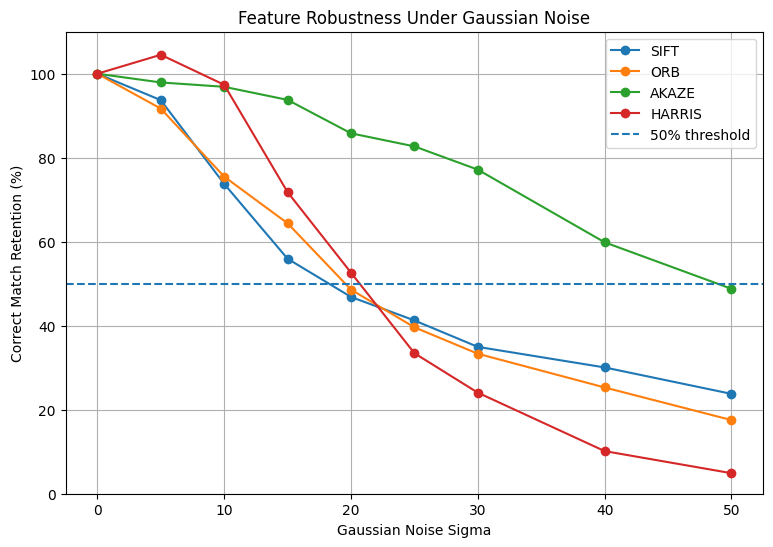

In [406]:
plt.figure(figsize=(9, 6))

for algorithm in algorithms:

    # Remove duplicate levels and keep the latest result
    unique_results = {
        r["level"]: r
        for r in all_noise_results[algorithm]
    }

    levels = sorted(unique_results.keys())

    x = levels
    y = [
        unique_results[level]["retention"]
        for level in levels
    ]

    plt.plot(
        x,
        y,
        marker="o",
        label=algorithm
    )

plt.axhline(
    y=50,
    linestyle="--",
    label="50% threshold"
)

plt.xlabel("Gaussian Noise Sigma")
plt.ylabel("Correct Match Retention (%)")
plt.title("Feature Robustness Under Gaussian Noise")

plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.show()

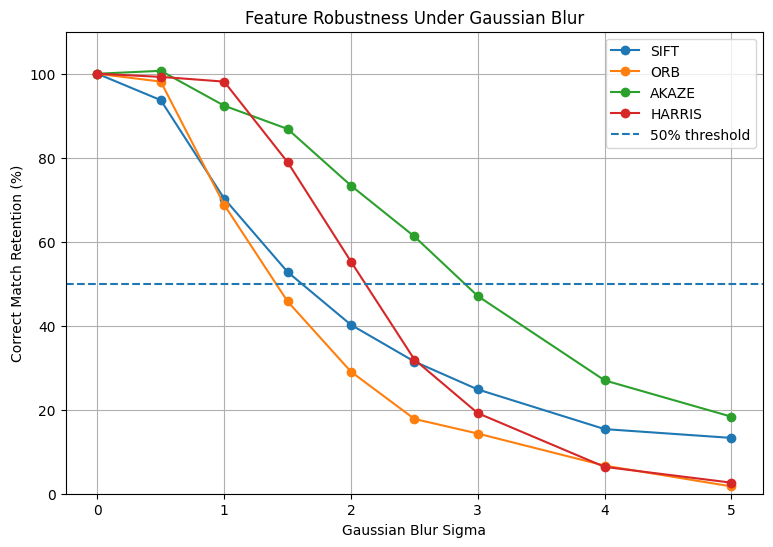

In [407]:
plt.figure(figsize=(9, 6))

for algorithm in algorithms:

    # Remove duplicate levels and keep the latest result
    unique_results = {
        r["level"]: r
        for r in all_blur_results[algorithm]
    }

    levels = sorted(unique_results.keys())

    x = levels
    y = [
        unique_results[level]["retention"]
        for level in levels
    ]

    plt.plot(
        x,
        y,
        marker="o",
        label=algorithm
    )

plt.axhline(
    y=50,
    linestyle="--",
    label="50% threshold"
)

plt.xlabel("Gaussian Blur Sigma")
plt.ylabel("Correct Match Retention (%)")
plt.title("Feature Robustness Under Gaussian Blur")

plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.show()

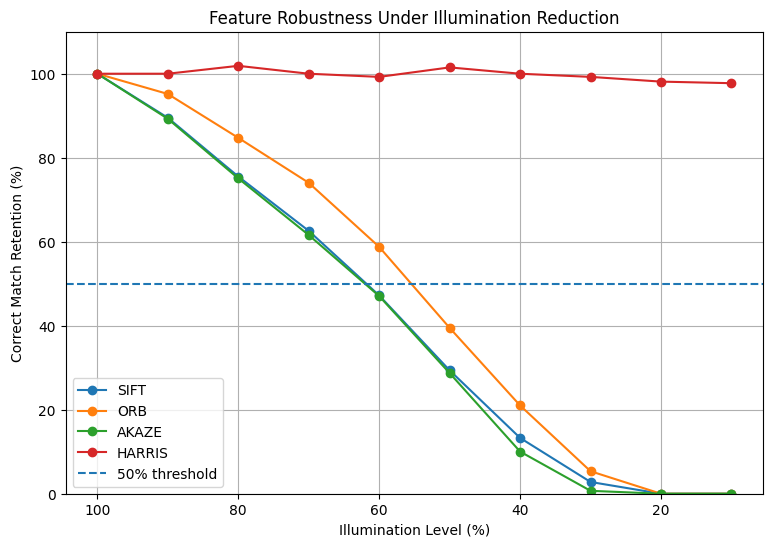

In [408]:
plt.figure(figsize=(9, 6))

for algorithm in algorithms:

    # Remove duplicate levels and keep the latest result
    unique_results = {
        r["level"]: r
        for r in all_light_results[algorithm]
    }

    # 100% → 10%
    levels = sorted(
        unique_results.keys(),
        reverse=True
    )

    x = levels
    y = [
        unique_results[level]["retention"]
        for level in levels
    ]

    plt.plot(
        x,
        y,
        marker="o",
        label=algorithm
    )

plt.axhline(
    y=50,
    linestyle="--",
    label="50% threshold"
)

plt.xlabel("Illumination Level (%)")
plt.ylabel("Correct Match Retention (%)")
plt.title("Feature Robustness Under Illumination Reduction")

plt.ylim(0, 110)

# 100% illumination on left → darker toward right
plt.gca().invert_xaxis()

plt.grid(True)
plt.legend()
plt.show()

# Stage I

Pilot sequences: 20
Processing 1/20: i_ajuntament
Processing 2/20: i_autannes
Processing 3/20: i_bologna
Processing 4/20: i_books
Processing 5/20: i_boutique
Processing 6/20: i_bridger
Processing 7/20: i_brooklyn
Processing 8/20: i_castle
Processing 9/20: i_chestnuts
Processing 10/20: i_contruction
Processing 11/20: v_abstract
Processing 12/20: v_adam
Processing 13/20: v_apprentices
Processing 14/20: v_artisans
Processing 15/20: v_astronautis
Processing 16/20: v_azzola
Processing 17/20: v_bark
Processing 18/20: v_bees
Processing 19/20: v_beyus
Processing 20/20: v_bip

===== RESULT COUNTS =====
Clean: 80
Noise: 720
Blur: 720
Illumination: 800

GAUSSIAN NOISE — POOLED RETENTION (%)
Level     SIFT          ORB           AKAZE         HARRIS        
----------------------------------------------------------------------
0         100.00        100.00        100.00        100.00        
5         91.67         94.67         98.67         98.91         
10        75.57         86.07         9

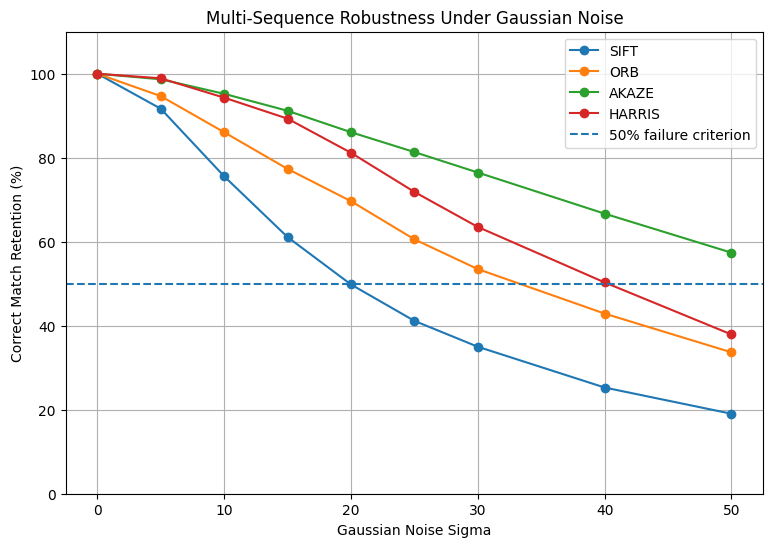

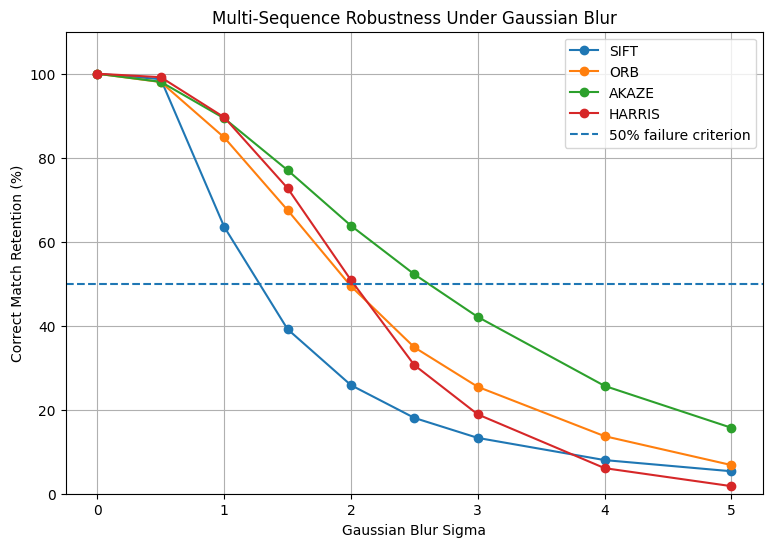

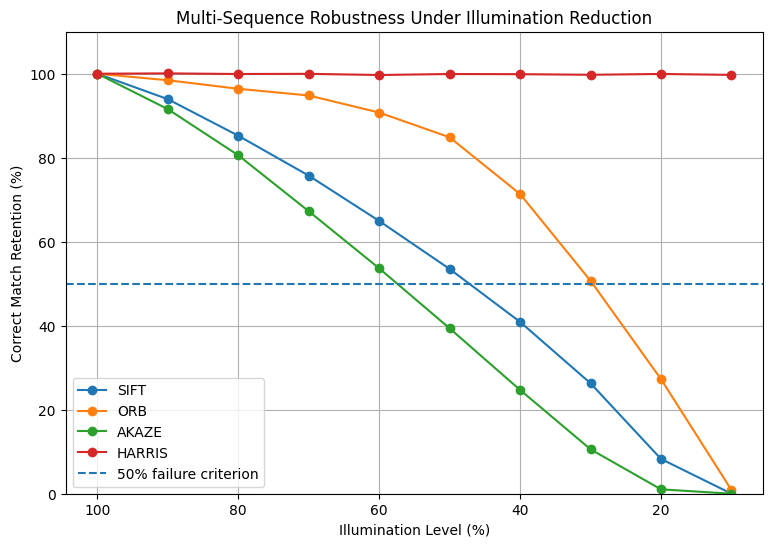

In [409]:
# ============================================================
# STAGE I MASTER CELL
# 20 HPATCHES SEQUENCES
# CLEAN + NOISE + BLUR + ILLUMINATION + THRESHOLDS
# ============================================================


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

pilot_sequences = (
    illumination_sequences[:10]
    +
    viewpoint_sequences[:10]
)

pilot_noise_levels = [
    0, 5, 10, 15, 20,
    25, 30, 40, 50
]

pilot_blur_levels = [
    0, 0.5, 1.0, 1.5, 2.0,
    2.5, 3.0, 4.0, 5.0
]

pilot_light_levels = [
    1.0, 0.9, 0.8, 0.7, 0.6,
    0.5, 0.4, 0.3, 0.2, 0.1
]


print("Pilot sequences:", len(pilot_sequences))


# ------------------------------------------------------------
# RESULT CONTAINERS
# ------------------------------------------------------------

pilot_clean_results = []
pilot_noise_results = []
pilot_blur_results = []
pilot_light_results = []

clean_lookup = {}


# ------------------------------------------------------------
# FAST EVALUATOR
# Reference features are already calculated and reused
# ------------------------------------------------------------

def evaluate_cached_reference(
    algorithm,
    ref_kp,
    ref_desc,
    norm,
    target_img,
    H_current
):

    target_kp, target_desc, _ = extract_features(
        algorithm,
        target_img
    )

    if (
        ref_desc is None
        or target_desc is None
        or len(ref_kp) < 2
        or len(target_kp) < 2
    ):

        return {
            "target_keypoints": len(target_kp),
            "good_matches": 0,
            "correct_matches": 0,
            "accuracy": 0,
            "median_error": np.nan
        }

    matcher = cv2.BFMatcher(norm)

    knn_matches = matcher.knnMatch(
        ref_desc,
        target_desc,
        k=2
    )

    good_matches = []

    for pair in knn_matches:

        if len(pair) != 2:
            continue

        m, n = pair

        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)


    correct_matches, accuracy, median_error = verify_matches(
        ref_kp,
        target_kp,
        good_matches,
        H_current
    )

    return {
        "target_keypoints": len(target_kp),
        "good_matches": len(good_matches),
        "correct_matches": len(correct_matches),
        "accuracy": accuracy,
        "median_error": median_error
    }


# ------------------------------------------------------------
# MAIN LOOP
# ------------------------------------------------------------

for sequence_index, sequence_name in enumerate(
    pilot_sequences
):

    print(
        f"Processing {sequence_index + 1}/"
        f"{len(pilot_sequences)}: "
        f"{sequence_name}"
    )

    ref_img, target_img, H_seq = load_hpatches_pair(
        sequence_name,
        target_number=2
    )

    sequence_type = (
        "illumination"
        if sequence_name.startswith("i_")
        else "viewpoint"
    )


    # --------------------------------------------------------
    # Cache reference features
    # --------------------------------------------------------

    reference_cache = {}

    for algorithm in algorithms:

        ref_kp, ref_desc, norm = extract_features(
            algorithm,
            ref_img
        )

        reference_cache[algorithm] = {
            "kp": ref_kp,
            "desc": ref_desc,
            "norm": norm
        }


    # --------------------------------------------------------
    # CLEAN BASELINE
    # --------------------------------------------------------

    clean_results_for_sequence = {}

    for algorithm in algorithms:

        ref_data = reference_cache[algorithm]

        result = evaluate_cached_reference(
            algorithm,
            ref_data["kp"],
            ref_data["desc"],
            ref_data["norm"],
            target_img,
            H_seq
        )

        clean_results_for_sequence[algorithm] = result

        clean_lookup[
            (sequence_name, algorithm)
        ] = result["correct_matches"]

        pilot_clean_results.append({

            "sequence": sequence_name,

            "type": sequence_type,

            "algorithm": algorithm,

            "reference_keypoints":
                len(ref_data["kp"]),

            "target_keypoints":
                result["target_keypoints"],

            "good_matches":
                result["good_matches"],

            "correct_matches":
                result["correct_matches"],

            "accuracy":
                result["accuracy"],

            "median_error":
                result["median_error"]
        })


    # --------------------------------------------------------
    # GAUSSIAN NOISE
    # --------------------------------------------------------

    for sigma_level in pilot_noise_levels:

        if sigma_level == 0:

            degraded_img = target_img

        else:

            # Different but reproducible noise for each sequence
            rng = np.random.default_rng(
                1000
                + sequence_index * 100
                + sigma_level
            )

            noise = rng.normal(
                0,
                sigma_level,
                target_img.shape
            )

            degraded_img = (
                target_img.astype(np.float32)
                + noise
            )

            degraded_img = np.clip(
                degraded_img,
                0,
                255
            ).astype(np.uint8)


        for algorithm in algorithms:

            if sigma_level == 0:

                result = clean_results_for_sequence[
                    algorithm
                ]

            else:

                ref_data = reference_cache[algorithm]

                result = evaluate_cached_reference(
                    algorithm,
                    ref_data["kp"],
                    ref_data["desc"],
                    ref_data["norm"],
                    degraded_img,
                    H_seq
                )


            baseline = clean_lookup[
                (sequence_name, algorithm)
            ]

            retention = (
                result["correct_matches"]
                / baseline
                * 100
                if baseline > 0
                else np.nan
            )

            pilot_noise_results.append({

                "sequence":
                    sequence_name,

                "type":
                    sequence_type,

                "algorithm":
                    algorithm,

                "sigma":
                    sigma_level,

                "correct_matches":
                    result["correct_matches"],

                "retention":
                    retention,

                "accuracy":
                    result["accuracy"]
            })


    # --------------------------------------------------------
    # GAUSSIAN BLUR
    # --------------------------------------------------------

    for blur_sigma in pilot_blur_levels:

        if blur_sigma == 0:

            degraded_img = target_img

        else:

            degraded_img = cv2.GaussianBlur(
                target_img,
                (0, 0),
                sigmaX=blur_sigma
            )


        for algorithm in algorithms:

            if blur_sigma == 0:

                result = clean_results_for_sequence[
                    algorithm
                ]

            else:

                ref_data = reference_cache[algorithm]

                result = evaluate_cached_reference(
                    algorithm,
                    ref_data["kp"],
                    ref_data["desc"],
                    ref_data["norm"],
                    degraded_img,
                    H_seq
                )


            baseline = clean_lookup[
                (sequence_name, algorithm)
            ]

            retention = (
                result["correct_matches"]
                / baseline
                * 100
                if baseline > 0
                else np.nan
            )

            pilot_blur_results.append({

                "sequence":
                    sequence_name,

                "type":
                    sequence_type,

                "algorithm":
                    algorithm,

                "sigma":
                    blur_sigma,

                "correct_matches":
                    result["correct_matches"],

                "retention":
                    retention,

                "accuracy":
                    result["accuracy"]
            })


    # --------------------------------------------------------
    # ILLUMINATION REDUCTION
    # --------------------------------------------------------

    for factor in pilot_light_levels:

        if factor == 1.0:

            degraded_img = target_img

        else:

            degraded_img = (
                target_img.astype(np.float32)
                * factor
            )

            degraded_img = np.clip(
                degraded_img,
                0,
                255
            ).astype(np.uint8)


        light_percent = int(
            round(factor * 100)
        )


        for algorithm in algorithms:

            if factor == 1.0:

                result = clean_results_for_sequence[
                    algorithm
                ]

            else:

                ref_data = reference_cache[algorithm]

                result = evaluate_cached_reference(
                    algorithm,
                    ref_data["kp"],
                    ref_data["desc"],
                    ref_data["norm"],
                    degraded_img,
                    H_seq
                )


            baseline = clean_lookup[
                (sequence_name, algorithm)
            ]

            retention = (
                result["correct_matches"]
                / baseline
                * 100
                if baseline > 0
                else np.nan
            )

            pilot_light_results.append({

                "sequence":
                    sequence_name,

                "type":
                    sequence_type,

                "algorithm":
                    algorithm,

                "light_percent":
                    light_percent,

                "correct_matches":
                    result["correct_matches"],

                "retention":
                    retention,

                "accuracy":
                    result["accuracy"]
            })


# ============================================================
# RESULT COUNT CHECK
# ============================================================

print("\n===== RESULT COUNTS =====")

print(
    "Clean:",
    len(pilot_clean_results)
)

print(
    "Noise:",
    len(pilot_noise_results)
)

print(
    "Blur:",
    len(pilot_blur_results)
)

print(
    "Illumination:",
    len(pilot_light_results)
)


# ============================================================
# POOLED RETENTION
# ============================================================

def create_pooled_summary(
    results,
    level_key,
    levels
):

    summary = {}

    for algorithm in algorithms:

        summary[algorithm] = []

        for level in levels:

            total_clean = 0
            total_degraded = 0

            sequence_retentions = []

            for r in results:

                if (
                    r["algorithm"] != algorithm
                    or r[level_key] != level
                ):
                    continue


                baseline = clean_lookup[
                    (
                        r["sequence"],
                        algorithm
                    )
                ]

                if baseline <= 0:
                    continue


                total_clean += baseline

                total_degraded += (
                    r["correct_matches"]
                )

                sequence_retentions.append(
                    r["correct_matches"]
                    / baseline
                    * 100
                )


            pooled_retention = (
                total_degraded
                / total_clean
                * 100
                if total_clean > 0
                else np.nan
            )


            median_retention = (
                np.median(
                    sequence_retentions
                )
                if sequence_retentions
                else np.nan
            )


            summary[algorithm].append({

                "level":
                    level,

                "pooled":
                    pooled_retention,

                "median":
                    median_retention,

                "n":
                    len(sequence_retentions)
            })


    return summary


noise_summary = create_pooled_summary(
    pilot_noise_results,
    "sigma",
    pilot_noise_levels
)

blur_summary = create_pooled_summary(
    pilot_blur_results,
    "sigma",
    pilot_blur_levels
)

light_percent_levels = [
    int(round(x * 100))
    for x in pilot_light_levels
]

light_summary = create_pooled_summary(
    pilot_light_results,
    "light_percent",
    light_percent_levels
)


# ============================================================
# FAILURE THRESHOLD
# ============================================================

def find_failure_threshold(
    summary,
    algorithm
):

    for row in summary[algorithm]:

        retention = row["pooled"]

        if (
            not np.isnan(retention)
            and retention < 50
        ):
            return row["level"]

    return None


# ============================================================
# PRINT POOLED RETENTION TABLE
# ============================================================

def print_retention_table(
    title,
    summary
):

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    print(
        f"{'Level':<10}"
        f"{'SIFT':<14}"
        f"{'ORB':<14}"
        f"{'AKAZE':<14}"
        f"{'HARRIS':<14}"
    )

    print("-" * 70)


    number_of_levels = len(
        summary["SIFT"]
    )


    for i in range(number_of_levels):

        level = summary[
            "SIFT"
        ][i]["level"]


        values = [
            summary[algorithm][i]["pooled"]
            for algorithm in algorithms
        ]


        print(
            f"{str(level):<10}"
            f"{values[0]:<14.2f}"
            f"{values[1]:<14.2f}"
            f"{values[2]:<14.2f}"
            f"{values[3]:<14.2f}"
        )


print_retention_table(
    "GAUSSIAN NOISE — POOLED RETENTION (%)",
    noise_summary
)

print_retention_table(
    "GAUSSIAN BLUR — POOLED RETENTION (%)",
    blur_summary
)

print_retention_table(
    "ILLUMINATION REDUCTION — POOLED RETENTION (%)",
    light_summary
)


# ============================================================
# FAILURE THRESHOLD TABLE
# ============================================================

print(
    "\n===== MULTI-SEQUENCE PILOT FAILURE THRESHOLDS ====="
)

print(
    f"{'Algorithm':<12}"
    f"{'Noise σ':<12}"
    f"{'Blur σ':<12}"
    f"{'Light %':<12}"
)

print("-" * 48)


pilot_thresholds = {}


for algorithm in algorithms:

    noise_threshold = find_failure_threshold(
        noise_summary,
        algorithm
    )

    blur_threshold = find_failure_threshold(
        blur_summary,
        algorithm
    )

    light_threshold = find_failure_threshold(
        light_summary,
        algorithm
    )


    pilot_thresholds[algorithm] = {

        "noise":
            noise_threshold,

        "blur":
            blur_threshold,

        "light":
            light_threshold
    }


    print(
        f"{algorithm:<12}"
        f"{str(noise_threshold):<12}"
        f"{str(blur_threshold):<12}"
        f"{str(light_threshold):<12}"
    )


# ============================================================
# PLOTS
# ============================================================

# -------------------- NOISE --------------------

plt.figure(figsize=(9, 6))

for algorithm in algorithms:

    x = [
        r["level"]
        for r in noise_summary[algorithm]
    ]

    y = [
        r["pooled"]
        for r in noise_summary[algorithm]
    ]

    plt.plot(
        x,
        y,
        marker="o",
        label=algorithm
    )


plt.axhline(
    50,
    linestyle="--",
    label="50% failure criterion"
)

plt.xlabel("Gaussian Noise Sigma")

plt.ylabel(
    "Correct Match Retention (%)"
)

plt.title(
    "Multi-Sequence Robustness Under Gaussian Noise"
)

plt.ylim(0, 110)

plt.grid(True)

plt.legend()

plt.show()


# -------------------- BLUR --------------------

plt.figure(figsize=(9, 6))

for algorithm in algorithms:

    x = [
        r["level"]
        for r in blur_summary[algorithm]
    ]

    y = [
        r["pooled"]
        for r in blur_summary[algorithm]
    ]

    plt.plot(
        x,
        y,
        marker="o",
        label=algorithm
    )


plt.axhline(
    50,
    linestyle="--",
    label="50% failure criterion"
)

plt.xlabel("Gaussian Blur Sigma")

plt.ylabel(
    "Correct Match Retention (%)"
)

plt.title(
    "Multi-Sequence Robustness Under Gaussian Blur"
)

plt.ylim(0, 110)

plt.grid(True)

plt.legend()

plt.show()


# -------------------- ILLUMINATION --------------------

plt.figure(figsize=(9, 6))

for algorithm in algorithms:

    x = [
        r["level"]
        for r in light_summary[algorithm]
    ]

    y = [
        r["pooled"]
        for r in light_summary[algorithm]
    ]

    plt.plot(
        x,
        y,
        marker="o",
        label=algorithm
    )


plt.axhline(
    50,
    linestyle="--",
    label="50% failure criterion"
)

plt.xlabel("Illumination Level (%)")

plt.ylabel(
    "Correct Match Retention (%)"
)

plt.title(
    "Multi-Sequence Robustness Under Illumination Reduction"
)

plt.ylim(0, 110)

plt.gca().invert_xaxis()

plt.grid(True)

plt.legend()

plt.show()

# Stage K

In [410]:
# ============================================================
# STAGE K — EXACT FAILURE THRESHOLD VALIDATION
# ============================================================

def get_threshold_transition(summary, algorithm):

    rows = summary[algorithm]

    for i, row in enumerate(rows):

        retention = row["pooled"]

        if not np.isnan(retention) and retention < 50:

            failure_level = row["level"]

            # Previous tested level that was still >= 50%
            if i > 0:
                previous_level = rows[i - 1]["level"]
                previous_retention = rows[i - 1]["pooled"]
            else:
                previous_level = None
                previous_retention = None

            return {
                "previous_level": previous_level,
                "previous_retention": previous_retention,
                "failure_level": failure_level,
                "failure_retention": retention
            }

    return None


print("\n===== VALIDATED PILOT FAILURE THRESHOLDS =====")

for algorithm in algorithms:

    print(f"\n{algorithm}")

    # ---------------- NOISE ----------------
    noise_result = get_threshold_transition(
        noise_summary,
        algorithm
    )

    if noise_result is None:

        print("  Noise: No failure within tested range")

    else:

        print(
            f"  Noise: "
            f"{noise_result['previous_level']} "
            f"({noise_result['previous_retention']:.2f}%)"
            f" → "
            f"{noise_result['failure_level']} "
            f"({noise_result['failure_retention']:.2f}%)"
        )


    # ---------------- BLUR ----------------
    blur_result = get_threshold_transition(
        blur_summary,
        algorithm
    )

    if blur_result is None:

        print("  Blur: No failure within tested range")

    else:

        print(
            f"  Blur: "
            f"{blur_result['previous_level']} "
            f"({blur_result['previous_retention']:.2f}%)"
            f" → "
            f"{blur_result['failure_level']} "
            f"({blur_result['failure_retention']:.2f}%)"
        )


    # ---------------- ILLUMINATION ----------------
    light_result = get_threshold_transition(
        light_summary,
        algorithm
    )

    if light_result is None:

        print(
            "  Illumination: "
            "No failure within tested range"
        )

    else:

        print(
            f"  Illumination: "
            f"{light_result['previous_level']}% "
            f"({light_result['previous_retention']:.2f}%)"
            f" → "
            f"{light_result['failure_level']}% "
            f"({light_result['failure_retention']:.2f}%)"
        )


===== VALIDATED PILOT FAILURE THRESHOLDS =====

SIFT
  Noise: 15 (61.10%) → 20 (49.82%)
  Blur: 1.0 (63.56%) → 1.5 (39.17%)
  Illumination: 50% (53.51%) → 40% (40.91%)

ORB
  Noise: 30 (53.48%) → 40 (42.89%)
  Blur: 1.5 (67.52%) → 2.0 (49.40%)
  Illumination: 30% (50.71%) → 20% (27.28%)

AKAZE
  Noise: No failure within tested range
  Blur: 2.5 (52.23%) → 3.0 (42.09%)
  Illumination: 60% (53.66%) → 50% (39.37%)

HARRIS
  Noise: 40 (50.31%) → 50 (37.92%)
  Blur: 2.0 (50.85%) → 2.5 (30.61%)
  Illumination: No failure within tested range


# Stage L

Enhancement methods: ['Global Equalization', 'CLAHE', 'Gamma']

===== STARTING STAGE L =====
Processing 1/20: i_ajuntament
Processing 2/20: i_autannes
Processing 3/20: i_bologna
Processing 4/20: i_books
Processing 5/20: i_boutique
Processing 6/20: i_bridger
Processing 7/20: i_brooklyn
Processing 8/20: i_castle
Processing 9/20: i_chestnuts
Processing 10/20: i_contruction
Processing 11/20: v_abstract
Processing 12/20: v_adam
Processing 13/20: v_apprentices
Processing 14/20: v_artisans
Processing 15/20: v_astronautis
Processing 16/20: v_azzola
Processing 17/20: v_bark
Processing 18/20: v_bees
Processing 19/20: v_beyus
Processing 20/20: v_bip

Stage L enhancement experiment finished.
Enhancement result records: 2040
Expected records: 2040

NOISE — ENHANCEMENT AT FAILURE/STRESS LEVEL
Algorithm   Level     Raw         Global Eq.     CLAHE       Gamma       
------------------------------------------------------------------------------------------
SIFT        20        49.82       40.45      

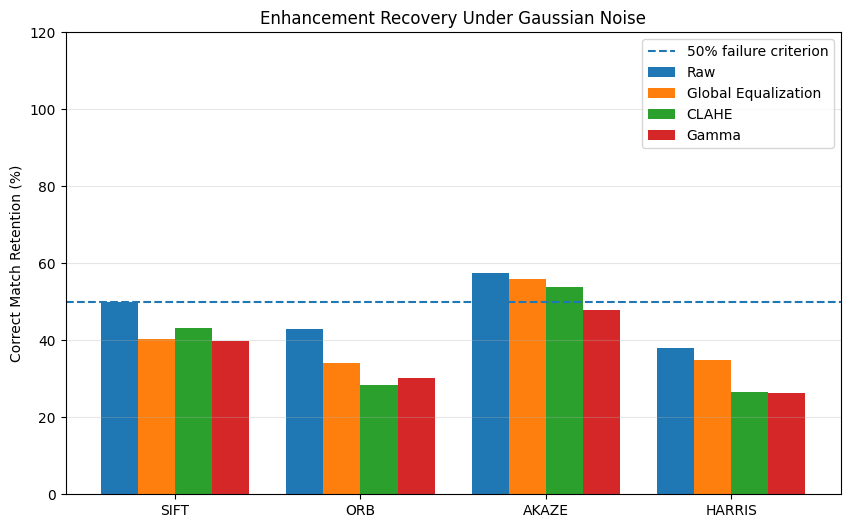

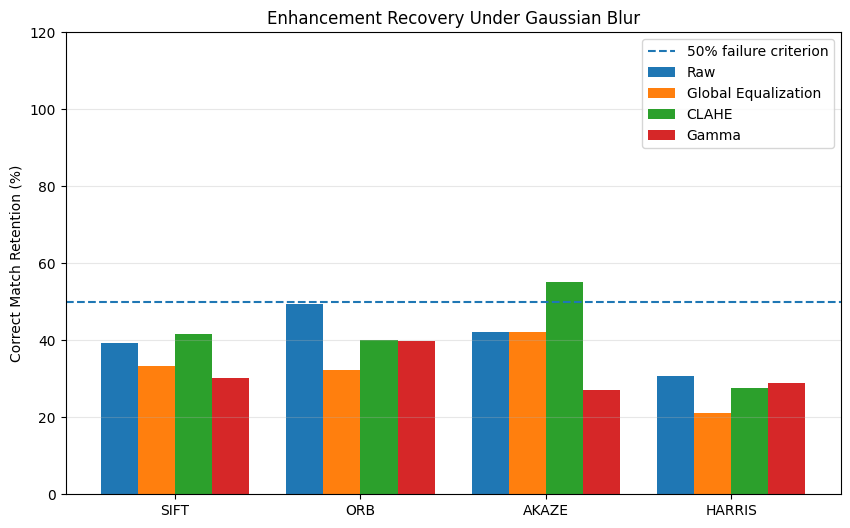

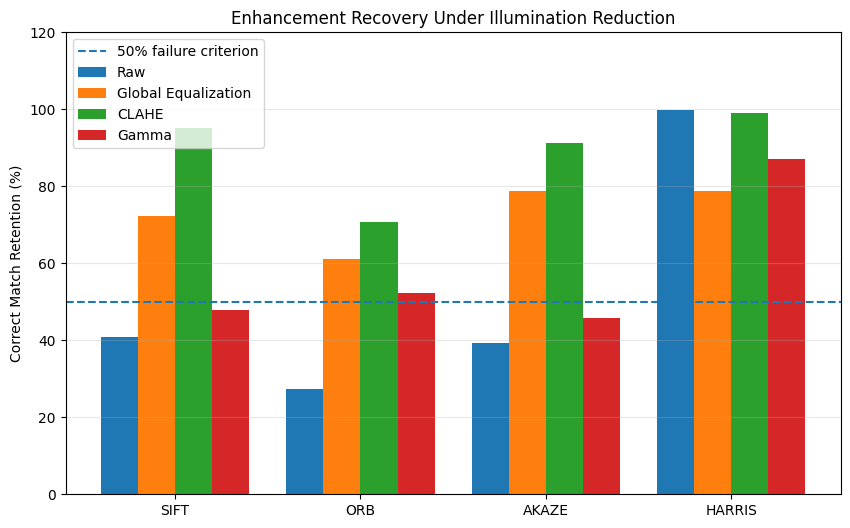

In [411]:
# ============================================================
# STAGE L — IMAGE ENHANCEMENT EXPERIMENT
#
# Tests:
#   1. Global Histogram Equalization
#   2. CLAHE
#   3. Gamma Correction



# ============================================================
# L1. ENHANCEMENT FUNCTIONS
# ============================================================

def enhance_global_contrast(image):
    """
    Global histogram equalization.
    """
    return cv2.equalizeHist(image)


def enhance_clahe(image):
    """
    Contrast Limited Adaptive Histogram Equalization.
    """
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    return clahe.apply(image)


def enhance_gamma(image, gamma=0.5):
    """
    Gamma correction.
    gamma < 1 brightens the image.
    """

    normalized = (
        image.astype(np.float32) / 255.0
    )

    corrected = np.power(
        normalized,
        gamma
    )

    corrected = np.clip(
        corrected * 255.0,
        0,
        255
    ).astype(np.uint8)

    return corrected


enhancement_methods = {

    "Global Equalization":
        enhance_global_contrast,

    "CLAHE":
        enhance_clahe,

    "Gamma":
        enhance_gamma
}


print(
    "Enhancement methods:",
    list(enhancement_methods.keys())
)


# ============================================================
# L2. TARGETED DEGRADATION LEVELS
# ============================================================
#
# These levels are based on Stage K.
#
# We test:
#   - level before failure
#   - first failure level
#   - one stronger level where possible
#
# For algorithms that did not fail:
#   severe tested levels are used instead.
# ============================================================


stage_l_levels = {

    "noise": {

        "SIFT":
            [15, 20, 25],

        "ORB":
            [30, 40, 50],

        "AKAZE":
            [40, 50],

        "HARRIS":
            [40, 50]
    },


    "blur": {

        "SIFT":
            [1.0, 1.5, 2.0],

        "ORB":
            [1.5, 2.0, 2.5],

        "AKAZE":
            [2.5, 3.0, 4.0],

        "HARRIS":
            [2.0, 2.5, 3.0]
    },


    "light": {

        "SIFT":
            [50, 40, 30],

        "ORB":
            [30, 20, 10],

        "AKAZE":
            [60, 50, 40],

        # Harris did not fail.
        # Test severe illumination reduction.
        "HARRIS":
            [30, 20, 10]
    }
}


# ============================================================
# L3. REFERENCE LEVEL FOR MAIN RECOVERY COMPARISON
# ============================================================
#
# For detectors that failed:
# use first failure level.
#
# For no-failure cases:
# use strongest/severe tested condition.
# ============================================================

stage_l_anchor_levels = {

    "noise": {
        "SIFT": 20,
        "ORB": 40,
        "AKAZE": 50,
        "HARRIS": 50
    },

    "blur": {
        "SIFT": 1.5,
        "ORB": 2.0,
        "AKAZE": 3.0,
        "HARRIS": 2.5
    },

    "light": {
        "SIFT": 40,
        "ORB": 20,
        "AKAZE": 50,
        "HARRIS": 10
    }
}


# ============================================================
# L4. RESET RESULT CONTAINER
# ============================================================

enhancement_results = []


# ============================================================
# L5. RUN ENHANCEMENT EXPERIMENT
# ============================================================

print(
    "\n===== STARTING STAGE L ====="
)



for sequence_index, sequence_name in enumerate(
    pilot_sequences
):

    print(
        f"Processing {sequence_index + 1}/"
        f"{len(pilot_sequences)}: "
        f"{sequence_name}"
    )


    # --------------------------------------------------------
    # Load sequence
    # --------------------------------------------------------

    ref_img, target_img, H_seq = load_hpatches_pair(
        sequence_name,
        target_number=2
    )


    sequence_type = (
        "illumination"
        if sequence_name.startswith("i_")
        else "viewpoint"
    )


    # --------------------------------------------------------
    # Cache reference features once
    # --------------------------------------------------------

    reference_cache = {}


    for algorithm in algorithms:

        ref_kp, ref_desc, norm = extract_features(
            algorithm,
            ref_img
        )

        reference_cache[algorithm] = {

            "kp":
                ref_kp,

            "desc":
                ref_desc,

            "norm":
                norm
        }


    # ========================================================
    # A. GAUSSIAN NOISE + ENHANCEMENT
    # ========================================================

    noise_union_levels = sorted(
        set(
            level
            for algorithm in algorithms
            for level in stage_l_levels[
                "noise"
            ][algorithm]
        )
    )


    for sigma_level in noise_union_levels:

        # Same seed structure used in Stage I
        rng = np.random.default_rng(
            1000
            + sequence_index * 100
            + sigma_level
        )


        noise = rng.normal(
            0,
            sigma_level,
            target_img.shape
        )


        degraded_img = (
            target_img.astype(np.float32)
            + noise
        )


        degraded_img = np.clip(
            degraded_img,
            0,
            255
        ).astype(np.uint8)


        # Generate enhanced versions once
        enhanced_versions = {

            method_name:
                method_function(
                    degraded_img
                )

            for method_name,
                method_function
            in enhancement_methods.items()
        }


        for algorithm in algorithms:

            # Only evaluate levels selected
            # for this algorithm
            if sigma_level not in stage_l_levels[
                "noise"
            ][algorithm]:

                continue


            baseline = clean_lookup[
                (
                    sequence_name,
                    algorithm
                )
            ]


            ref_data = reference_cache[
                algorithm
            ]


            for method_name, enhanced_img in (
                enhanced_versions.items()
            ):


                result = evaluate_cached_reference(

                    algorithm,

                    ref_data["kp"],

                    ref_data["desc"],

                    ref_data["norm"],

                    enhanced_img,

                    H_seq
                )


                retention = (
                    result["correct_matches"]
                    / baseline
                    * 100
                    if baseline > 0
                    else np.nan
                )


                enhancement_results.append({

                    "sequence":
                        sequence_name,

                    "type":
                        sequence_type,

                    "degradation":
                        "noise",

                    "level":
                        sigma_level,

                    "algorithm":
                        algorithm,

                    "enhancement":
                        method_name,

                    "correct_matches":
                        result[
                            "correct_matches"
                        ],

                    "retention":
                        retention,

                    "accuracy":
                        result["accuracy"]
                })


    # ========================================================
    # B. GAUSSIAN BLUR + ENHANCEMENT
    # ========================================================

    blur_union_levels = sorted(
        set(
            level
            for algorithm in algorithms
            for level in stage_l_levels[
                "blur"
            ][algorithm]
        )
    )


    for blur_sigma in blur_union_levels:


        degraded_img = cv2.GaussianBlur(
            target_img,
            (0, 0),
            sigmaX=blur_sigma
        )


        enhanced_versions = {

            method_name:
                method_function(
                    degraded_img
                )

            for method_name,
                method_function
            in enhancement_methods.items()
        }


        for algorithm in algorithms:


            if blur_sigma not in stage_l_levels[
                "blur"
            ][algorithm]:

                continue


            baseline = clean_lookup[
                (
                    sequence_name,
                    algorithm
                )
            ]


            ref_data = reference_cache[
                algorithm
            ]


            for method_name, enhanced_img in (
                enhanced_versions.items()
            ):


                result = evaluate_cached_reference(

                    algorithm,

                    ref_data["kp"],

                    ref_data["desc"],

                    ref_data["norm"],

                    enhanced_img,

                    H_seq
                )


                retention = (
                    result["correct_matches"]
                    / baseline
                    * 100
                    if baseline > 0
                    else np.nan
                )


                enhancement_results.append({

                    "sequence":
                        sequence_name,

                    "type":
                        sequence_type,

                    "degradation":
                        "blur",

                    "level":
                        blur_sigma,

                    "algorithm":
                        algorithm,

                    "enhancement":
                        method_name,

                    "correct_matches":
                        result[
                            "correct_matches"
                        ],

                    "retention":
                        retention,

                    "accuracy":
                        result["accuracy"]
                })


    # ========================================================
    # C. ILLUMINATION REDUCTION + ENHANCEMENT
    # ========================================================

    light_union_levels = sorted(
        set(
            level
            for algorithm in algorithms
            for level in stage_l_levels[
                "light"
            ][algorithm]
        ),
        reverse=True
    )


    for light_percent in light_union_levels:


        light_factor = (
            light_percent / 100.0
        )


        degraded_img = (
            target_img.astype(np.float32)
            * light_factor
        )


        degraded_img = np.clip(
            degraded_img,
            0,
            255
        ).astype(np.uint8)


        enhanced_versions = {

            method_name:
                method_function(
                    degraded_img
                )

            for method_name,
                method_function
            in enhancement_methods.items()
        }


        for algorithm in algorithms:


            if light_percent not in stage_l_levels[
                "light"
            ][algorithm]:

                continue


            baseline = clean_lookup[
                (
                    sequence_name,
                    algorithm
                )
            ]


            ref_data = reference_cache[
                algorithm
            ]


            for method_name, enhanced_img in (
                enhanced_versions.items()
            ):


                result = evaluate_cached_reference(

                    algorithm,

                    ref_data["kp"],

                    ref_data["desc"],

                    ref_data["norm"],

                    enhanced_img,

                    H_seq
                )


                retention = (
                    result["correct_matches"]
                    / baseline
                    * 100
                    if baseline > 0
                    else np.nan
                )


                enhancement_results.append({

                    "sequence":
                        sequence_name,

                    "type":
                        sequence_type,

                    "degradation":
                        "light",

                    "level":
                        light_percent,

                    "algorithm":
                        algorithm,

                    "enhancement":
                        method_name,

                    "correct_matches":
                        result[
                            "correct_matches"
                        ],

                    "retention":
                        retention,

                    "accuracy":
                        result["accuracy"]
                })


print(
    "\nStage L enhancement experiment finished."
)


print(
    "Enhancement result records:",
    len(enhancement_results)
)


# ============================================================
# L6. EXPECTED RESULT COUNT
# ============================================================

levels_per_sequence = (

    sum(
        len(
            stage_l_levels[
                "noise"
            ][algorithm]
        )
        for algorithm in algorithms
    )

    +

    sum(
        len(
            stage_l_levels[
                "blur"
            ][algorithm]
        )
        for algorithm in algorithms
    )

    +

    sum(
        len(
            stage_l_levels[
                "light"
            ][algorithm]
        )
        for algorithm in algorithms
    )
)


expected_enhancement_records = (

    len(pilot_sequences)

    * levels_per_sequence

    * len(enhancement_methods)
)


print(
    "Expected records:",
    expected_enhancement_records
)


# ============================================================
# L7. POOLED ENHANCEMENT RETENTION
# ============================================================

def pooled_enhancement_retention(
    degradation,
    algorithm,
    level,
    enhancement
):

    selected = [

        r
        for r in enhancement_results

        if (
            r["degradation"]
            == degradation

            and r["algorithm"]
            == algorithm

            and r["level"]
            == level

            and r["enhancement"]
            == enhancement
        )
    ]


    total_clean = 0

    total_enhanced = 0


    for r in selected:

        baseline = clean_lookup[
            (
                r["sequence"],
                algorithm
            )
        ]


        if baseline <= 0:
            continue


        total_clean += baseline

        total_enhanced += (
            r["correct_matches"]
        )


    if total_clean == 0:
        return np.nan


    return (
        total_enhanced
        / total_clean
        * 100
    )


# ============================================================
# L8. GET RAW RETENTION FROM STAGE I
# ============================================================

def raw_pooled_retention(
    degradation,
    algorithm,
    level
):

    if degradation == "noise":

        source_results = (
            pilot_noise_results
        )

        level_key = "sigma"


    elif degradation == "blur":

        source_results = (
            pilot_blur_results
        )

        level_key = "sigma"


    else:

        source_results = (
            pilot_light_results
        )

        level_key = "light_percent"


    selected = [

        r
        for r in source_results

        if (
            r["algorithm"]
            == algorithm

            and r[level_key]
            == level
        )
    ]


    total_clean = 0

    total_degraded = 0


    for r in selected:


        baseline = clean_lookup[
            (
                r["sequence"],
                algorithm
            )
        ]


        if baseline <= 0:
            continue


        total_clean += baseline

        total_degraded += (
            r["correct_matches"]
        )


    if total_clean == 0:
        return np.nan


    return (
        total_degraded
        / total_clean
        * 100
    )


# ============================================================
# L9. PRINT MAIN RECOVERY TABLES
# ============================================================

def print_enhancement_comparison(
    degradation,
    title
):

    print(
        "\n"
        + "=" * 90
    )

    print(title)

    print(
        "=" * 90
    )


    print(
        f"{'Algorithm':<12}"
        f"{'Level':<10}"
        f"{'Raw':<12}"
        f"{'Global Eq.':<15}"
        f"{'CLAHE':<12}"
        f"{'Gamma':<12}"
    )


    print("-" * 90)


    for algorithm in algorithms:


        level = stage_l_anchor_levels[
            degradation
        ][algorithm]


        raw_value = raw_pooled_retention(
            degradation,
            algorithm,
            level
        )


        global_value = (
            pooled_enhancement_retention(

                degradation,
                algorithm,
                level,
                "Global Equalization"
            )
        )


        clahe_value = (
            pooled_enhancement_retention(

                degradation,
                algorithm,
                level,
                "CLAHE"
            )
        )


        gamma_value = (
            pooled_enhancement_retention(

                degradation,
                algorithm,
                level,
                "Gamma"
            )
        )


        print(
            f"{algorithm:<12}"
            f"{str(level):<10}"
            f"{raw_value:<12.2f}"
            f"{global_value:<15.2f}"
            f"{clahe_value:<12.2f}"
            f"{gamma_value:<12.2f}"
        )


print_enhancement_comparison(

    "noise",

    "NOISE — ENHANCEMENT AT FAILURE/STRESS LEVEL"
)


print_enhancement_comparison(

    "blur",

    "BLUR — ENHANCEMENT AT FAILURE LEVEL"
)


print_enhancement_comparison(

    "light",

    "ILLUMINATION — ENHANCEMENT AT FAILURE/STRESS LEVEL"
)


# ============================================================
# L10. RECOVERY GAIN TABLE
# ============================================================

print(
    "\n===== RECOVERY GAIN AT SELECTED LEVELS ====="
)


for degradation in [
    "noise",
    "blur",
    "light"
]:

    print(
        f"\n--- {degradation.upper()} ---"
    )


    for algorithm in algorithms:


        level = stage_l_anchor_levels[
            degradation
        ][algorithm]


        raw_value = raw_pooled_retention(
            degradation,
            algorithm,
            level
        )


        method_values = {}


        for method_name in enhancement_methods:


            enhanced_value = (
                pooled_enhancement_retention(

                    degradation,
                    algorithm,
                    level,
                    method_name
                )
            )


            method_values[
                method_name
            ] = enhanced_value


        valid_methods = {

            name: value

            for name, value
            in method_values.items()

            if not np.isnan(value)
        }


        if not valid_methods:

            print(
                algorithm,
                ": no valid results"
            )

            continue


        best_method = max(
            valid_methods,
            key=valid_methods.get
        )


        best_value = valid_methods[
            best_method
        ]


        gain = (
            best_value
            - raw_value
        )


        print(

            f"{algorithm:<8} | "

            f"Level: {level:<5} | "

            f"Raw: {raw_value:6.2f}% | "

            f"Best: {best_method:<20} | "

            f"Enhanced: {best_value:6.2f}% | "

            f"Gain: {gain:+6.2f} percentage points"
        )


# ============================================================
# L11. BAR PLOTS AT FAILURE/STRESS LEVEL
# ============================================================

plot_methods = [
    "Raw",
    "Global Equalization",
    "CLAHE",
    "Gamma"
]


def plot_enhancement_recovery(
    degradation,
    title
):

    x = np.arange(
        len(algorithms)
    )


    width = 0.2


    for method_index, method in enumerate(
        plot_methods
    ):


        values = []


        for algorithm in algorithms:


            level = stage_l_anchor_levels[
                degradation
            ][algorithm]


            if method == "Raw":

                value = raw_pooled_retention(
                    degradation,
                    algorithm,
                    level
                )


            else:

                value = (
                    pooled_enhancement_retention(

                        degradation,
                        algorithm,
                        level,
                        method
                    )
                )


            values.append(value)


        offset = (
            method_index - 1.5
        ) * width


        plt.bar(
            x + offset,
            values,
            width,
            label=method
        )


    plt.axhline(
        50,
        linestyle="--",
        label="50% failure criterion"
    )


    plt.xticks(
        x,
        algorithms
    )


    plt.ylabel(
        "Correct Match Retention (%)"
    )


    plt.title(title)


    plt.ylim(
        0,
        120
    )


    plt.grid(
        axis="y",
        alpha=0.3
    )


    plt.legend()


    plt.show()


# Noise
plt.figure(
    figsize=(10, 6)
)

plot_enhancement_recovery(

    "noise",

    "Enhancement Recovery Under Gaussian Noise"
)


# Blur
plt.figure(
    figsize=(10, 6)
)

plot_enhancement_recovery(

    "blur",

    "Enhancement Recovery Under Gaussian Blur"
)


# Illumination
plt.figure(
    figsize=(10, 6)
)

plot_enhancement_recovery(

    "light",

    "Enhancement Recovery Under Illumination Reduction"
)




# Stage M


In [412]:
# ============================================================
# STAGE M — FAILURE THRESHOLD EXTENSION ANALYSIS
# ============================================================


# ------------------------------------------------------------
# M1. FIND RAW / ENHANCED TRANSITIONS
# ------------------------------------------------------------

def get_local_threshold_status(
    degradation,
    algorithm,
    method=None
):

    # IMPORTANT:
    # stage_l_levels are already ordered from
    # lower degradation -> stronger degradation
    levels = stage_l_levels[
        degradation
    ][algorithm]


    values = []


    for level in levels:

        if method is None:

            retention = raw_pooled_retention(
                degradation,
                algorithm,
                level
            )

        else:

            retention = pooled_enhancement_retention(
                degradation,
                algorithm,
                level,
                method
            )


        values.append(
            {
                "level": level,
                "retention": retention
            }
        )


    # Find first tested level below 50%
    for i, row in enumerate(values):

        retention = row["retention"]

        if (
            not np.isnan(retention)
            and retention < 50
        ):

            previous = (
                values[i - 1]
                if i > 0
                else None
            )

            return {
                "status": "failure",
                "failure_level":
                    row["level"],
                "failure_retention":
                    retention,
                "previous_level":
                    (
                        previous["level"]
                        if previous
                        else None
                    ),
                "previous_retention":
                    (
                        previous["retention"]
                        if previous
                        else None
                    ),
                "values":
                    values
            }


    # Never fell below 50%
    return {
        "status": "no_failure",
        "failure_level": None,
        "failure_retention": None,
        "previous_level": None,
        "previous_retention": None,
        "values": values
    }


# ------------------------------------------------------------
# M2. PRINT LOCAL RETENTION CURVES
# ------------------------------------------------------------

for degradation in [
    "noise",
    "blur",
    "light"
]:

    print(
        "\n"
        + "=" * 85
    )

    print(
        f"{degradation.upper()} — "
        f"THRESHOLD EXTENSION ANALYSIS"
    )

    print(
        "=" * 85
    )


    for algorithm in algorithms:

        print(
            f"\n{algorithm}"
        )


        levels = stage_l_levels[
            degradation
        ][algorithm]


        print(
            f"{'Level':<10}"
            f"{'Raw':<12}"
            f"{'Global Eq.':<15}"
            f"{'CLAHE':<12}"
            f"{'Gamma':<12}"
        )

        print("-" * 61)


        for level in levels:

            raw_value = raw_pooled_retention(
                degradation,
                algorithm,
                level
            )

            global_value = (
                pooled_enhancement_retention(
                    degradation,
                    algorithm,
                    level,
                    "Global Equalization"
                )
            )

            clahe_value = (
                pooled_enhancement_retention(
                    degradation,
                    algorithm,
                    level,
                    "CLAHE"
                )
            )

            gamma_value = (
                pooled_enhancement_retention(
                    degradation,
                    algorithm,
                    level,
                    "Gamma"
                )
            )


            print(
                f"{str(level):<10}"
                f"{raw_value:<12.2f}"
                f"{global_value:<15.2f}"
                f"{clahe_value:<12.2f}"
                f"{gamma_value:<12.2f}"
            )


# ------------------------------------------------------------
# M3. SUMMARIZE WHETHER EACH METHOD DELAYS FAILURE
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 95
)

print(
    "STAGE M — ENHANCEMENT FAILURE-THRESHOLD SUMMARY"
)

print(
    "=" * 95
)


for degradation in [
    "noise",
    "blur",
    "light"
]:

    print(
        f"\n--- {degradation.upper()} ---"
    )


    for algorithm in algorithms:

        raw_status = get_local_threshold_status(
            degradation,
            algorithm,
            method=None
        )


        print(
            f"\n{algorithm}"
        )


        if (
            raw_status["status"]
            == "failure"
        ):

            print(
                "  Raw first failure:",
                raw_status[
                    "failure_level"
                ]
            )

        else:

            print(
                "  Raw: no failure "
                "within Stage L range"
            )


        for method_name in enhancement_methods:

            enhanced_status = (
                get_local_threshold_status(
                    degradation,
                    algorithm,
                    method=method_name
                )
            )


            if (
                enhanced_status["status"]
                == "failure"
            ):

                print(
                    f"  {method_name}: "
                    f"first failure at "
                    f"{enhanced_status['failure_level']}"
                )

            else:

                print(
                    f"  {method_name}: "
                    "no failure within "
                    "tested Stage L range"
                )


# ------------------------------------------------------------
# M4. IDENTIFY WHETHER THE FIRST RAW FAILURE WAS RECOVERED
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 95
)

print(
    "RECOVERY OF RAW FAILURE LEVEL"
)

print(
    "=" * 95
)


for degradation in [
    "noise",
    "blur",
    "light"
]:

    print(
        f"\n--- {degradation.upper()} ---"
    )


    for algorithm in algorithms:

        # Stage K threshold
        if degradation == "noise":

            raw_transition = (
                get_threshold_transition(
                    noise_summary,
                    algorithm
                )
            )

        elif degradation == "blur":

            raw_transition = (
                get_threshold_transition(
                    blur_summary,
                    algorithm
                )
            )

        else:

            raw_transition = (
                get_threshold_transition(
                    light_summary,
                    algorithm
                )
            )


        if raw_transition is None:

            print(
                f"{algorithm:<8}: "
                "No original failure "
                "within tested range"
            )

            continue


        failure_level = (
            raw_transition[
                "failure_level"
            ]
        )


        # Only evaluate if Stage L tested
        # that failure level
        if failure_level not in (
            stage_l_levels[
                degradation
            ][algorithm]
        ):

            print(
                f"{algorithm:<8}: "
                "failure level not included "
                "in Stage L"
            )

            continue


        raw_value = raw_pooled_retention(
            degradation,
            algorithm,
            failure_level
        )


        print(
            f"\n{algorithm} | "
            f"Raw failure level = "
            f"{failure_level} | "
            f"Raw retention = "
            f"{raw_value:.2f}%"
        )


        for method_name in enhancement_methods:

            enhanced_value = (
                pooled_enhancement_retention(
                    degradation,
                    algorithm,
                    failure_level,
                    method_name
                )
            )


            recovered = (
                enhanced_value >= 50
            )


            status_text = (
                "RECOVERED"
                if recovered
                else "NOT RECOVERED"
            )


            print(
                f"   "
                f"{method_name:<20}"
                f"{enhanced_value:6.2f}%  "
                f"{status_text}"
            )


print(
    "\n===== STAGE M COMPLETE ====="
)


NOISE — THRESHOLD EXTENSION ANALYSIS

SIFT
Level     Raw         Global Eq.     CLAHE       Gamma       
-------------------------------------------------------------
15        61.10       47.38          52.27       48.43       
20        49.82       40.45          43.11       39.83       
25        41.15       35.13          36.18       32.47       

ORB
Level     Raw         Global Eq.     CLAHE       Gamma       
-------------------------------------------------------------
30        53.48       40.90          34.21       37.14       
40        42.89       34.21          28.49       30.15       
50        33.67       28.40          24.78       25.26       

AKAZE
Level     Raw         Global Eq.     CLAHE       Gamma       
-------------------------------------------------------------
40        66.68       63.64          60.23       53.55       
50        57.39       55.79          53.74       47.87       

HARRIS
Level     Raw         Global Eq.     CLAHE       Gamma       
------

# Stage N

In [413]:
# ============================================================
# STAGE N — SAVE PILOT RESULTS
# ============================================================

import pandas as pd

pd.DataFrame(pilot_clean_results).to_csv(
    "/content/pilot_clean_results.csv",
    index=False
)

pd.DataFrame(pilot_noise_results).to_csv(
    "/content/pilot_noise_results.csv",
    index=False
)

pd.DataFrame(pilot_blur_results).to_csv(
    "/content/pilot_blur_results.csv",
    index=False
)

pd.DataFrame(pilot_light_results).to_csv(
    "/content/pilot_light_results.csv",
    index=False
)

pd.DataFrame(enhancement_results).to_csv(
    "/content/pilot_enhancement_results.csv",
    index=False
)

print("Pilot results saved successfully.")

Pilot results saved successfully.


In [415]:
import zipfile
from google.colab import files

result_files = [
    "/content/pilot_clean_results.csv",
    "/content/pilot_noise_results.csv",
    "/content/pilot_blur_results.csv",
    "/content/pilot_light_results.csv",
    "/content/pilot_enhancement_results.csv"
]

zip_name = "/content/CSE463_experiment_results.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file_path in result_files:
        zipf.write(
            file_path,
            arcname=file_path.split("/")[-1]
        )

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>